# Self-Refine across model sizes

This notebook extends the small-tier Self-Refine analysis
(`3_self_refine.ipynb`) to **all three model tiers** so the thesis can show
whether the Self-Refine effect *scales with model size*:

| tier | size band | families |
|------|-----------|----------|
| `very_small` | 4–9B  | Gemma 3 4B, Ministral 3 8B, Qwen3.5 9B |
| `small`      | 12–14B | Gemma 3 12B, Ministral 3 14B, Qwen3 14B |
| `medium`     | 24–27B | Gemma 3 27B, Mistral Small 24B, Qwen3.5 27B |

The experiment is self-play: in every game both seats are the same model, and
each of the four strategy assignments is run 30 times per model. The
assignments are coded by two letters, the first for Player 1 and the second for
Player 2, with `D` = default and `R` = self-refine:

| code | Player 1 | Player 2 |
|------|----------|----------|
| `DD` | default  | default  |
| `RD` | refine   | default  |
| `DR` | default  | refine   |
| `RR` | refine   | refine   |

Each analysis section produces (a) **per-tier facet** figures — the same view as
the small-tier notebook, one figure per tier — and (b) a **tier-trend** summary
figure that puts model size on the x-axis. Figures are written to
`_notebooks/oss/figures/3_self_refine/`.

## Executive summary — does Self-Refine help?

**Short answer: not as a general-purpose improver.** Across the full
3 tiers × 3 games × 4 conditions grid, the payoff and win-rate effects of
Self-Refine overwhelmingly straddle zero, and on the smallest tier the loop even
*lowers* completion. What the data does show is two narrow, mechanistic
benefits, and one robust positive case:

1. **Format / completion is the one reliable, size-scaling win.** For `small`
   and `medium` models the loop lifts completion in every game, and the lift
   *grows with model size* — Trading `+0.05 → +0.12 → +0.18`, BuySell
   `-0.07 → +0.04 → +0.09`, Ultimatum `-0.04 → +0.04 → +0.10`
   (very_small → small → medium). The share of refined moves that end with
   *no parseable proposal* falls from `0.37` to `0.28` across tiers: bigger
   models spend the extra calls turning a malformed draft into a valid move.
   On `very_small` this reverses — the loop hurts BuySell and Ultimatum
   completion — so the benefit is **capability-gated**.

2. **Refinement pulls whichever seat runs it toward parity** — it
   *redistributes* advantage rather than adding it. A seat that starts behind
   tends to gain; a seat that starts ahead tends to give ground. This is visible
   in win rate at every tier and is the engine behind the one clear positive
   case below.

3. **The one CI-robust, size-stable positive case is the Trading first mover.**
   Refining P1 in Trading — the seat that loses on default — raises payoff
   `+1.4 → +2.2 → +2.4` (CIs clear zero at `small` and `medium`) and win rate
   `+0.15 → +0.19 → +0.15` at all three tiers. It is driven by Ministral (small)
   and Qwen (medium). Nowhere else does a pooled seat effect clear zero at more
   than one tier.

The sections below substantiate each claim with per-tier figures and the
tier-trend summaries.

In [1]:
import sys, os, json, warnings
from pathlib import Path


def find_repo_root():
    starts = []
    seen = set()

    def add_start(path_like):
        if not path_like:
            return
        try:
            path = Path(path_like).resolve()
        except (FileNotFoundError, OSError, RuntimeError):
            return
        key = str(path)
        if key not in seen:
            seen.add(key)
            starts.append(path)

    if "__file__" in globals():
        add_start(Path(__file__).resolve().parent)
    try:
        add_start(Path.cwd())
    except (FileNotFoundError, OSError, RuntimeError):
        pass
    add_start(os.environ.get("PWD"))
    for start in starts:
        for candidate in (start, *start.parents):
            if ((candidate / ".logs").exists()
                    and (candidate / "configs").exists()
                    and (candidate / "_notebooks").exists()):
                return candidate
    raise FileNotFoundError("Could not find repository root")


ROOT_DIR = find_repo_root()
sys.path.insert(0, str(ROOT_DIR))
sys.path.insert(0, str(ROOT_DIR / "_notebooks" / "oss" / "style"))
sys.path.insert(0, str(ROOT_DIR / "explorer"))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore")

import style
from style import wilson_ci, bootstrap_ci, errbars_from_ci, win_rate, family_of
# Publication design system (_notebooks/oss/style): sans-serif report skin,
# colorblind palette, value-axis gridlines, and constrained layout.
style.apply_thesis_style()
FULL_WIDTH, HALF_WIDTH = style.FULL_WIDTH, style.HALF_WIDTH

NOTEBOOK_NAME = "3_self_refine"
FIG_DIR = ROOT_DIR / "_notebooks" / "oss" / "figures" / NOTEBOOK_NAME
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_plot(fig, slug):
    """Save without the descriptive whole-figure title (the LaTeX caption supplies
    it); keep panel titles and keep the title for the inline display. Writes a PNG."""
    hidden = []
    sup = getattr(fig, "_suptitle", None)
    if sup is not None and sup.get_text():
        sup.set_visible(False); hidden.append(sup)
    real_axes = [a for a in fig.axes if a.get_label() != "<colorbar>"]
    if len(real_axes) == 1 and real_axes[0].get_title():
        t = real_axes[0].title
        t.set_visible(False); hidden.append(t)
    for ext in ("png",):
        fig.savefig(FIG_DIR / f"{slug}.{ext}", dpi=300, bbox_inches="tight")
    for artist in hidden:
        artist.set_visible(True)
    return FIG_DIR / f"{slug}.png"


def print_plot_frame(name, df, columns=None, sort_by=None, round_cols=None):
    out = df.copy()
    if columns is not None:
        out = out.loc[:, columns]
    if sort_by is not None:
        out = out.sort_values(sort_by).reset_index(drop=True)
    if round_cols:
        for col, digits in round_cols.items():
            if col in out.columns:
                out[col] = out[col].round(digits)
    print(f"PLOT_DATA[{name}]")
    print(out.to_json(orient="records"))


# All three tiers, in increasing-size order, with their display labels.
SIZES = list(style.SIZE_ORDER)            # ["very_small", "small", "medium"]
SIZE_LABEL = style.SIZE_LABEL             # {"very_small": "4-9B", ...}
GAME_ORDER = ["Trading", "Ultimatum", "BuySell"]
COND_ORDER = ["DD", "RD", "DR", "RR"]
COND_LABEL = {"DD": "default", "RD": "refine P1", "DR": "refine P2", "RR": "both refine"}
# Strategy-condition palette (orange baseline, blue single-seat refine, green both).
COND_COLORS = {"DD": "#de8f05", "RD": "#0173b2", "DR": "#0173b2", "RR": "#029e73"}
# Focal-party setting palette for the seat-controlled comparison.
SETTING_ORDER = ["default", "refine", "both"]
SETTING_LABEL = {"default": "default", "refine": "refine (one seat)", "both": "both refine"}
SETTING_COLORS = {"default": "#de8f05", "refine": "#0173b2", "both": "#029e73"}
# Process direction palette (matches the Streamlit page).
DIRECTION_ORDER = ["more_selfish", "unchanged", "more_generous", "no_proposal"]
DIRECTION_LABEL = {"more_selfish": "more selfish", "unchanged": "unchanged",
                   "more_generous": "more generous", "no_proposal": "no proposal"}
DIRECTION_COLORS = {"more_selfish": "#de8f05", "unchanged": "#0173b2",
                    "more_generous": "#029e73", "no_proposal": "#949494"}
GAME_NATIVE_UNIT = {"Trading": "resource delta", "Ultimatum": "dollars kept",
                    "BuySell": "surplus (ZUP)"}
# Per-tier colors for the trend figures.
SIZE_COLORS = {"very_small": "#56b4e9", "small": "#0173b2", "medium": "#012a4a"}

# Lowercase game keys as they appear in the trace frames (TRACE/TSUM), plus a
# display map back to the title-case names used everywhere else.
games_l = ["trading", "ultimatum", "buysell"]
game_disp = {"trading": "Trading", "ultimatum": "Ultimatum", "buysell": "BuySell"}

In [2]:
from analysis.self_refine import (
    load_trading_sr, load_ultimatum_sr, load_buysell_sr, completion_rows,
)
from analysis.self_refine_process import load_trace_rows, load_trace_summary

_LOADERS = {"Trading": load_trading_sr, "Ultimatum": load_ultimatum_sr,
            "BuySell": load_buysell_sr}

# Nested outcome frames: OUT[size][game]. A tier/game with no logs yields an
# empty frame, which every plotting helper below guards against.
OUT, COMP = {}, {}
for sz in SIZES:
    OUT[sz] = {}
    for g, loader in _LOADERS.items():
        df = loader(sz)
        if len(df):
            df["game"] = g
            df["family"] = df["model"].map(family_of)
        OUT[sz][g] = df
    COMP[sz] = completion_rows(sz)

# Trace frames carry every size; keep them whole and filter per tier in-section.
TRACE_ALL = load_trace_rows()
TSUM_ALL = load_trace_summary()

# Sample sizes: completed decisive games underpin every win rate, so show them.
for sz in SIZES:
    rows = []
    for g in GAME_ORDER:
        df = OUT[sz][g]
        for c in COND_ORDER:
            sub = df[df["cond"] == c] if len(df) else df
            decisive = int((sub["win_1"] | sub["win_2"]).sum()) if len(sub) else 0
            rows.append({"game": g, "cond": c, "completed": len(sub),
                         "decisive": decisive})
    tbl = (pd.DataFrame(rows)
           .pivot_table(index="game", columns="cond",
                        values=["completed", "decisive"])
           .reindex(GAME_ORDER))
    print(f"=== {sz} ({SIZE_LABEL[sz]}) : completed runs / decisive games ===")
    print(tbl.to_string())
    print()

2026-06-18 10:02:36.837 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-06-18 10:02:36.843 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-06-18 10:02:39.473 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-06-18 10:02:39.474 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 10:02:48.936 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-06-18 10:02:48.936 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


=== very_small (4–9B) : completed runs / decisive games ===
          completed                   decisive                  
cond             DD    DR    RD    RR       DD    DR    RD    RR
game                                                            
Trading        63.0  66.0  63.0  74.0     46.0  53.0  47.0  58.0
Ultimatum      74.0  70.0  74.0  66.0     37.0  34.0  45.0  37.0
BuySell        65.0  67.0  52.0  58.0     38.0  49.0  39.0  42.0

=== small (12–14B) : completed runs / decisive games ===
          completed                   decisive                  
cond             DD    DR    RD    RR       DD    DR    RD    RR
game                                                            
Trading        77.0  89.0  89.0  86.0     61.0  74.0  81.0  78.0
Ultimatum      80.0  89.0  83.0  78.0     59.0  67.0  59.0  62.0
BuySell        84.0  88.0  87.0  87.0     70.0  82.0  78.0  85.0

=== medium (24–27B) : completed runs / decisive games ===
          completed                   decis

## 1. Completion

One of the five critique axes is *format*: whether every required tag is present
and parseable. The per-tier facets repeat the small-tier completion view for each
size; the trend figure then puts size on the x-axis so the format effect of
refinement can be read against model scale.

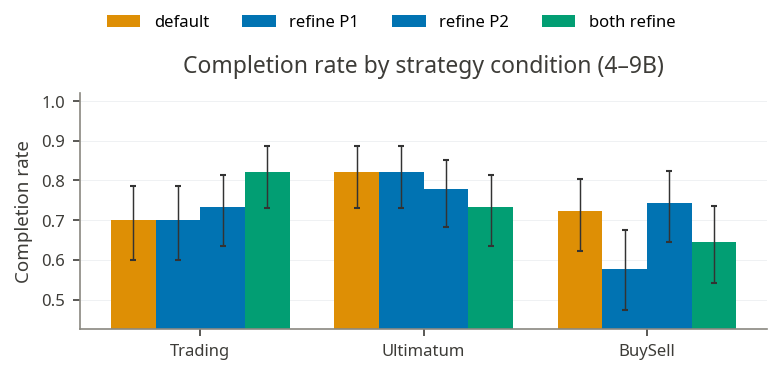

PLOT_DATA[completion_by_condition_very_small]
[{"game":"BuySell","cond":"DD","k":65,"n":90,"rate":0.722222,"lo":0.622048,"hi":0.804203},{"game":"BuySell","cond":"DR","k":67,"n":90,"rate":0.744444,"lo":0.645624,"hi":0.823252},{"game":"BuySell","cond":"RD","k":52,"n":90,"rate":0.577778,"lo":0.474612,"hi":0.674576},{"game":"BuySell","cond":"RR","k":58,"n":90,"rate":0.644444,"lo":0.541502,"hi":0.735561},{"game":"Trading","cond":"DD","k":63,"n":90,"rate":0.7,"lo":0.598735,"hi":0.784891},{"game":"Trading","cond":"DR","k":66,"n":90,"rate":0.733333,"lo":0.633802,"hi":0.813762},{"game":"Trading","cond":"RD","k":63,"n":90,"rate":0.7,"lo":0.598735,"hi":0.784891},{"game":"Trading","cond":"RR","k":74,"n":90,"rate":0.822222,"lo":0.730561,"hi":0.887503},{"game":"Ultimatum","cond":"DD","k":74,"n":90,"rate":0.822222,"lo":0.730561,"hi":0.887503},{"game":"Ultimatum","cond":"DR","k":70,"n":90,"rate":0.777778,"lo":0.681527,"hi":0.851287},{"game":"Ultimatum","cond":"RD","k":74,"n":90,"rate":0.822222,"lo":0.

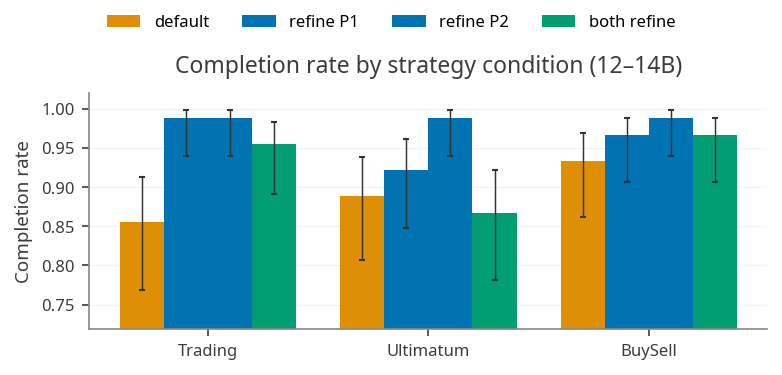

PLOT_DATA[completion_by_condition_small]
[{"game":"BuySell","cond":"DD","k":84,"n":90,"rate":0.933333,"lo":0.862099,"hi":0.96909},{"game":"BuySell","cond":"DR","k":89,"n":90,"rate":0.988889,"lo":0.939716,"hi":0.998036},{"game":"BuySell","cond":"RD","k":87,"n":90,"rate":0.966667,"lo":0.906527,"hi":0.9886},{"game":"BuySell","cond":"RR","k":87,"n":90,"rate":0.966667,"lo":0.906527,"hi":0.9886},{"game":"Trading","cond":"DD","k":77,"n":90,"rate":0.855556,"lo":0.768401,"hi":0.9136},{"game":"Trading","cond":"DR","k":89,"n":90,"rate":0.988889,"lo":0.939716,"hi":0.998036},{"game":"Trading","cond":"RD","k":89,"n":90,"rate":0.988889,"lo":0.939716,"hi":0.998036},{"game":"Trading","cond":"RR","k":86,"n":90,"rate":0.955556,"lo":0.891231,"hi":0.982583},{"game":"Ultimatum","cond":"DD","k":80,"n":90,"rate":0.888889,"lo":0.807422,"hi":0.938517},{"game":"Ultimatum","cond":"DR","k":89,"n":90,"rate":0.988889,"lo":0.939716,"hi":0.998036},{"game":"Ultimatum","cond":"RD","k":83,"n":90,"rate":0.922222,"lo":0.84

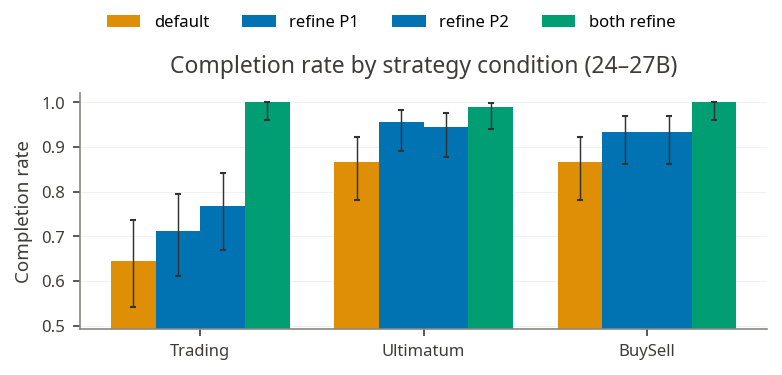

PLOT_DATA[completion_by_condition_medium]
[{"game":"BuySell","cond":"DD","k":78,"n":90,"rate":0.866667,"lo":0.781261,"hi":0.922053},{"game":"BuySell","cond":"DR","k":84,"n":90,"rate":0.933333,"lo":0.862099,"hi":0.96909},{"game":"BuySell","cond":"RD","k":84,"n":90,"rate":0.933333,"lo":0.862099,"hi":0.96909},{"game":"BuySell","cond":"RR","k":90,"n":90,"rate":1.0,"lo":0.959064,"hi":1.0},{"game":"Trading","cond":"DD","k":58,"n":90,"rate":0.644444,"lo":0.541502,"hi":0.735561},{"game":"Trading","cond":"DR","k":69,"n":90,"rate":0.766667,"lo":0.669483,"hi":0.842018},{"game":"Trading","cond":"RD","k":64,"n":90,"rate":0.711111,"lo":0.61036,"hi":0.794579},{"game":"Trading","cond":"RR","k":90,"n":90,"rate":1.0,"lo":0.959064,"hi":1.0},{"game":"Ultimatum","cond":"DD","k":78,"n":90,"rate":0.866667,"lo":0.781261,"hi":0.922053},{"game":"Ultimatum","cond":"DR","k":85,"n":90,"rate":0.944444,"lo":0.876463,"hi":0.976039},{"game":"Ultimatum","cond":"RD","k":86,"n":90,"rate":0.955556,"lo":0.891231,"hi":0.982

In [3]:
# Per-tier completion facet: completion rate by strategy condition, one figure
# per tier. Mirrors the small-tier notebook's `completion_by_condition`.
def plot_completion(sz):
    comp = COMP[sz]
    if comp is None or comp.empty:
        print(f"[skip] no completion data for {sz}")
        return None
    cc = (comp.groupby(["game", "cond"])
          .agg(k=("completed", "sum"), n=("completed", "count")).reset_index())
    cc["rate"] = cc["k"] / cc["n"]
    cc[["lo", "hi"]] = cc.apply(lambda r: pd.Series(wilson_ci(r.k, r.n)), axis=1)
    games_present = [g for g in GAME_ORDER if g in set(cc["game"])]
    x = np.arange(len(games_present)); width = 0.2
    fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.85, 2.4))
    for i, c in enumerate(COND_ORDER):
        sub = cc[cc["cond"] == c].set_index("game").reindex(games_present)
        pos = x + (i - 1.5) * width
        ax.bar(pos, sub["rate"], width, label=COND_LABEL[c], color=COND_COLORS[c])
        ax.errorbar(pos, sub["rate"],
                    yerr=errbars_from_ci(sub["rate"].values, list(zip(sub["lo"], sub["hi"]))),
                    fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
    ymin = max(0.0, float(cc[["rate", "lo"]].min().min()) - 0.05)
    ax.set_xticks(x, games_present); ax.set_ylabel("Completion rate")
    ax.set_ylim(ymin, 1.02)
    ax.set_title(f"Completion rate by strategy condition ({SIZE_LABEL[sz]})")
    fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center",
               ncols=4, frameon=False)
    save_plot(fig, f"completion_by_condition_{sz}"); plt.show()
    print_plot_frame(
        f"completion_by_condition_{sz}", cc,
        columns=["game", "cond", "k", "n", "rate", "lo", "hi"],
        sort_by=["game", "cond"],
        round_cols={"rate": 6, "lo": 6, "hi": 6})
    return cc


COMP_BY_TIER = {sz: plot_completion(sz) for sz in SIZES}

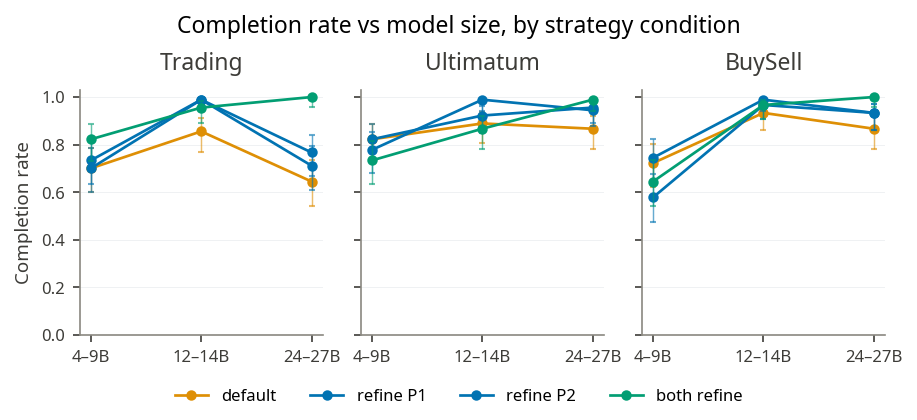

PLOT_DATA[completion_by_tier]
[{"game":"BuySell","cond":"DD","size":"medium","n":90,"rate":0.866667,"lo":0.781261,"hi":0.922053},{"game":"BuySell","cond":"DD","size":"small","n":90,"rate":0.933333,"lo":0.862099,"hi":0.96909},{"game":"BuySell","cond":"DD","size":"very_small","n":90,"rate":0.722222,"lo":0.622048,"hi":0.804203},{"game":"BuySell","cond":"DR","size":"medium","n":90,"rate":0.933333,"lo":0.862099,"hi":0.96909},{"game":"BuySell","cond":"DR","size":"small","n":90,"rate":0.988889,"lo":0.939716,"hi":0.998036},{"game":"BuySell","cond":"DR","size":"very_small","n":90,"rate":0.744444,"lo":0.645624,"hi":0.823252},{"game":"BuySell","cond":"RD","size":"medium","n":90,"rate":0.933333,"lo":0.862099,"hi":0.96909},{"game":"BuySell","cond":"RD","size":"small","n":90,"rate":0.966667,"lo":0.906527,"hi":0.9886},{"game":"BuySell","cond":"RD","size":"very_small","n":90,"rate":0.577778,"lo":0.474612,"hi":0.674576},{"game":"BuySell","cond":"RR","size":"medium","n":90,"rate":1.0,"lo":0.959064,"hi":

In [4]:
# Tier trend: completion rate vs model size, one panel per game, one line per
# strategy condition. Reads whether Self-Refine's format lift survives across
# scale.
trend_rows = []
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.7), sharey=True)
xs = np.arange(len(SIZES))
for ax, g in zip(axes, GAME_ORDER):
    for c in COND_ORDER:
        ys, los, his = [], [], []
        for sz in SIZES:
            cc = COMP_BY_TIER.get(sz)
            if cc is None:
                ys.append(np.nan); los.append(np.nan); his.append(np.nan); continue
            row = cc[(cc["game"] == g) & (cc["cond"] == c)]
            if len(row):
                r = row.iloc[0]
                ys.append(r["rate"]); los.append(r["lo"]); his.append(r["hi"])
                trend_rows.append(dict(game=g, cond=c, size=sz, rate=r["rate"],
                                       lo=r["lo"], hi=r["hi"], n=int(r["n"])))
            else:
                ys.append(np.nan); los.append(np.nan); his.append(np.nan)
        ys = np.array(ys, float)
        ax.plot(xs, ys, marker="o", ms=4, lw=1.3, color=COND_COLORS[c],
                label=COND_LABEL[c])
        ax.errorbar(xs, ys, yerr=errbars_from_ci(ys, list(zip(los, his))),
                    fmt="none", ecolor=COND_COLORS[c], lw=0.7, capsize=1.5, alpha=0.6)
    ax.set_xticks(xs, [SIZE_LABEL[s] for s in SIZES])
    ax.set_title(g); ax.set_ylim(0, 1.03)
axes[0].set_ylabel("Completion rate")
fig.suptitle("Completion rate vs model size, by strategy condition")
# de-duplicate the legend (RD and DR share a color/label group)
h, l = axes[0].get_legend_handles_labels()
seen = dict(zip(l, h))
fig.legend(seen.values(), seen.keys(), loc="outside lower center", ncols=4, frameon=False)
save_plot(fig, "completion_by_tier"); plt.show()

print_plot_frame(
    "completion_by_tier", pd.DataFrame(trend_rows),
    columns=["game", "cond", "size", "k" if False else "n", "rate", "lo", "hi"],
    sort_by=["game", "cond", "size"],
    round_cols={"rate": 6, "lo": 6, "hi": 6})

**Reading section 1.** Completion is the clearest place Self-Refine earns its
five extra calls — but only once the base model is competent enough to run the
loop. On `very_small` the refine conditions sit *below* the `DD` baseline in
BuySell (`-0.07`) and Ultimatum (`-0.04`): the 4–9B models often turn a passable
draft into a malformed one. From `small` upward the sign flips and the gap
widens monotonically with size (Trading `+0.12 → +0.18`). The `completion_by_tier`
trend panels show the four condition lines fanning *apart* as size grows, with
`RR` (both refine) reaching `1.00` in Trading and BuySell at `medium`. So the
format benefit is real, consistent across games, and **scales with capability** —
the opposite of a fixed-cost overhead.

## 2. Refining the first mover is not the same as refining the second

Each seat is compared against its own seat-matched `DD` baseline:

- **refine P1** is Player 1 in `RD` versus Player 1 in `DD`,
- **refine P2** is Player 2 in `DR` versus Player 2 in `DD`,
- **both refine** is each seat read from `RR`.

The per-tier facets give the payoff bars for each size; the trend figure tracks
the seat-specific refine effect (refine-this-seat minus the seat-matched `DD`
baseline) across model size.

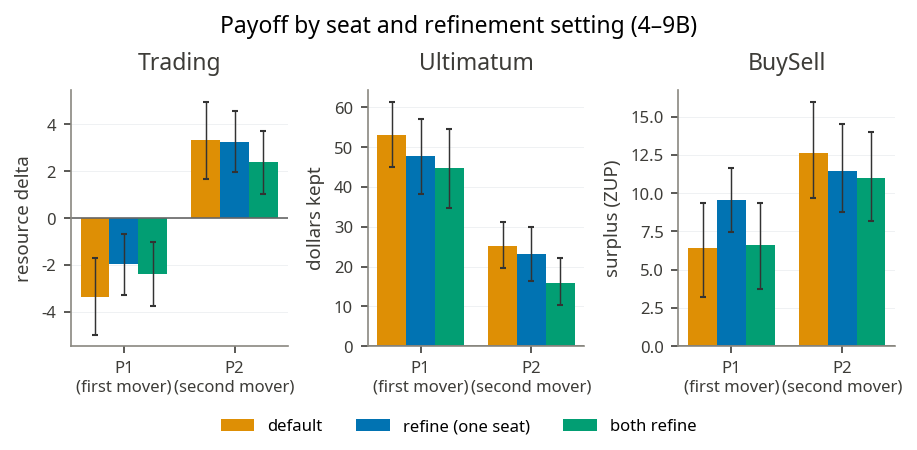

PLOT_DATA[refine_effect_by_seat_very_small]
[{"game":"BuySell","seat":1,"setting":"both","n":58,"mean":6.603448,"lo":3.706897,"hi":9.344828},{"game":"BuySell","seat":1,"setting":"default","n":65,"mean":6.446154,"lo":3.215385,"hi":9.323077},{"game":"BuySell","seat":1,"setting":"refine","n":52,"mean":9.538462,"lo":7.480769,"hi":11.634615},{"game":"BuySell","seat":2,"setting":"both","n":58,"mean":10.982759,"lo":8.189224,"hi":14.017241},{"game":"BuySell","seat":2,"setting":"default","n":65,"mean":12.630769,"lo":9.676923,"hi":15.938462},{"game":"BuySell","seat":2,"setting":"refine","n":67,"mean":11.462687,"lo":8.776119,"hi":14.477985},{"game":"Trading","seat":1,"setting":"both","n":74,"mean":-2.391892,"lo":-3.72973,"hi":-1.026689},{"game":"Trading","seat":1,"setting":"default","n":63,"mean":-3.349206,"lo":-4.968651,"hi":-1.68254},{"game":"Trading","seat":1,"setting":"refine","n":63,"mean":-1.936508,"lo":-3.285714,"hi":-0.666667},{"game":"Trading","seat":2,"setting":"both","n":74,"mean":2.39

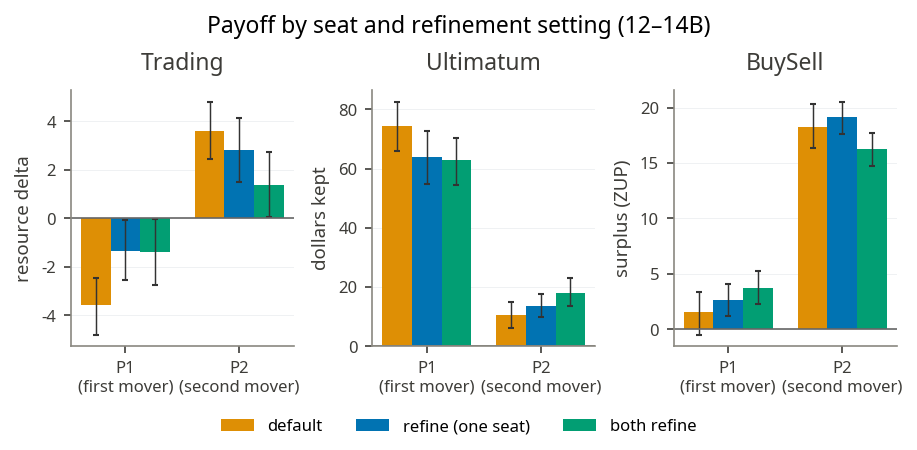

PLOT_DATA[refine_effect_by_seat_small]
[{"game":"BuySell","seat":1,"setting":"both","n":87,"mean":3.770115,"lo":2.298851,"hi":5.264368},{"game":"BuySell","seat":1,"setting":"default","n":84,"mean":1.547619,"lo":-0.464286,"hi":3.416667},{"game":"BuySell","seat":1,"setting":"refine","n":87,"mean":2.678161,"lo":1.229885,"hi":4.103448},{"game":"BuySell","seat":2,"setting":"both","n":87,"mean":16.229885,"lo":14.735632,"hi":17.701149},{"game":"BuySell","seat":2,"setting":"default","n":84,"mean":18.214286,"lo":16.309226,"hi":20.285714},{"game":"BuySell","seat":2,"setting":"refine","n":88,"mean":19.102273,"lo":17.625,"hi":20.534375},{"game":"Trading","seat":1,"setting":"both","n":86,"mean":-1.383721,"lo":-2.744186,"hi":-0.034884},{"game":"Trading","seat":1,"setting":"default","n":77,"mean":-3.571429,"lo":-4.805195,"hi":-2.454545},{"game":"Trading","seat":1,"setting":"refine","n":89,"mean":-1.337079,"lo":-2.573034,"hi":-0.089888},{"game":"Trading","seat":2,"setting":"both","n":86,"mean":1.38372

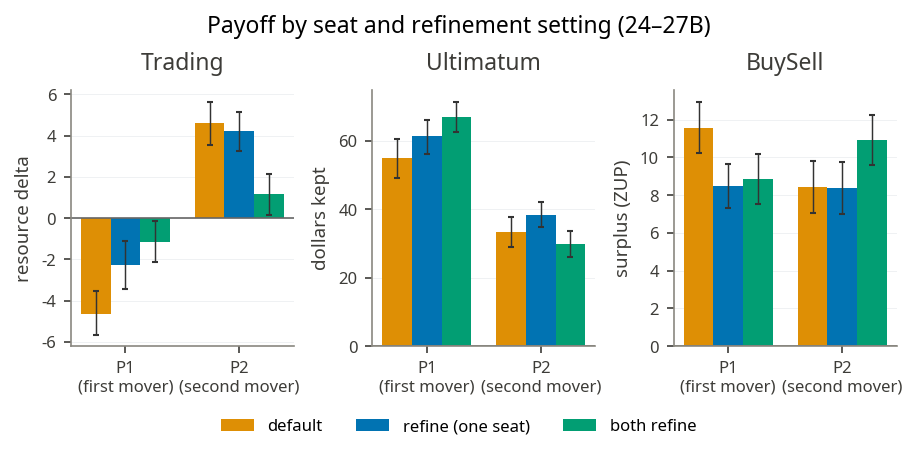

PLOT_DATA[refine_effect_by_seat_medium]
[{"game":"BuySell","seat":1,"setting":"both","n":90,"mean":8.844444,"lo":7.533333,"hi":10.155556},{"game":"BuySell","seat":1,"setting":"default","n":78,"mean":11.564103,"lo":10.205128,"hi":12.923077},{"game":"BuySell","seat":1,"setting":"refine","n":84,"mean":8.5,"lo":7.297619,"hi":9.666667},{"game":"BuySell","seat":2,"setting":"both","n":90,"mean":10.933333,"lo":9.6,"hi":12.266667},{"game":"BuySell","seat":2,"setting":"default","n":78,"mean":8.435897,"lo":7.076923,"hi":9.794872},{"game":"BuySell","seat":2,"setting":"refine","n":84,"mean":8.369048,"lo":6.999702,"hi":9.75},{"game":"Trading","seat":1,"setting":"both","n":90,"mean":-1.155556,"lo":-2.144444,"hi":-0.144444},{"game":"Trading","seat":1,"setting":"default","n":58,"mean":-4.637931,"lo":-5.655172,"hi":-3.534483},{"game":"Trading","seat":1,"setting":"refine","n":64,"mean":-2.265625,"lo":-3.421875,"hi":-1.09375},{"game":"Trading","seat":2,"setting":"both","n":90,"mean":1.155556,"lo":0.144444

In [5]:
# Seat-resolved comparisons reused by both the facet figures and the trend
# figures below. Every comparison is against the seat-matched DD baseline.
SEAT_SETTING = ["default", "refine", "both"]
_SEAT_COND = {(1, "default"): "DD", (1, "refine"): "RD", (1, "both"): "RR",
              (2, "default"): "DD", (2, "refine"): "DR", (2, "both"): "RR"}


def seat_payoff(df, seat, setting):
    if not len(df):
        return np.array([], float)
    col = "payoff_1" if seat == 1 else "payoff_2"
    return df[df["cond"] == _SEAT_COND[(seat, setting)]][col].values.astype(float)


def seat_winrate(df, seat, setting):
    if not len(df):
        return np.nan, 0, 0
    sub = df[df["cond"] == _SEAT_COND[(seat, setting)]]
    if seat == 1:
        w, l = int(sub["win_1"].sum()), int(sub["win_2"].sum())
    else:
        w, l = int(sub["win_2"].sum()), int(sub["win_1"].sum())
    return win_rate(w, l)


def _diff_ci(ref, base, n=4000, seed=0):
    ref, base = np.asarray(ref, float), np.asarray(base, float)
    if not len(ref) or not len(base):
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    d = [rng.choice(ref, ref.size).mean() - rng.choice(base, base.size).mean()
         for _ in range(n)]
    return float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5))


# Per-tier facet: one panel per game, two seat groups (P1, P2), each with
# default / refine-this-seat / both bars carrying bootstrap CIs.
def plot_seat_payoff(sz):
    out = OUT[sz]
    games_present = [g for g in GAME_ORDER if len(out[g])]
    if not games_present:
        print(f"[skip] no payoff data for {sz}")
        return None
    seat_plot = []
    fig, axes = plt.subplots(1, len(games_present), figsize=(FULL_WIDTH, 2.9),
                             squeeze=False)
    axes = axes[0]
    group_x = np.arange(2); width = 0.26
    for ax, g in zip(axes, games_present):
        df = out[g]
        for i, s in enumerate(SEAT_SETTING):
            centers, los, his = [], [], []
            for seat in (1, 2):
                vals = seat_payoff(df, seat, s)
                center = np.mean(vals) if len(vals) else np.nan
                lo, hi = bootstrap_ci(vals)
                centers.append(center); los.append(lo); his.append(hi)
                seat_plot.append(dict(size=sz, game=g, seat=seat, setting=s,
                                      n=len(vals), mean=center, lo=lo, hi=hi))
            pos = group_x + (i - 1) * width
            ax.bar(pos, centers, width, label=SETTING_LABEL[s], color=SETTING_COLORS[s])
            ax.errorbar(pos, centers,
                        yerr=errbars_from_ci(np.array(centers, float), list(zip(los, his))),
                        fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
        ax.axhline(0, lw=0.8, color="0.4")
        ax.set_xticks(group_x, ["P1\n(first mover)", "P2\n(second mover)"])
        ax.set_title(g); ax.set_ylabel(GAME_NATIVE_UNIT[g])
    fig.suptitle(f"Payoff by seat and refinement setting ({SIZE_LABEL[sz]})")
    fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
               ncols=3, frameon=False)
    save_plot(fig, f"refine_effect_by_seat_{sz}"); plt.show()
    print_plot_frame(
        f"refine_effect_by_seat_{sz}", pd.DataFrame(seat_plot),
        columns=["game", "seat", "setting", "n", "mean", "lo", "hi"],
        sort_by=["game", "seat", "setting"],
        round_cols={"mean": 6, "lo": 6, "hi": 6})
    return pd.DataFrame(seat_plot)


for sz in SIZES:
    plot_seat_payoff(sz)

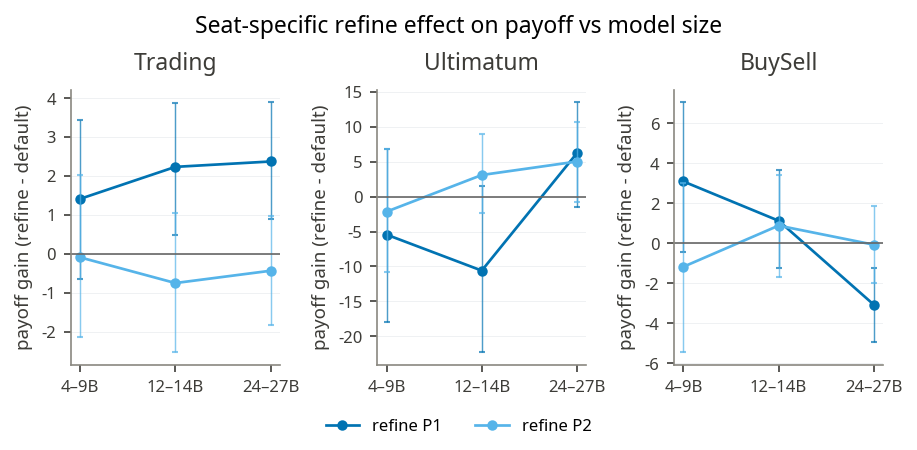

PLOT_DATA[refine_payoff_effect_by_tier]
[{"game":"BuySell","seat":"P1","size":"medium","n":84,"delta":-3.064103,"lo":-4.929853,"hi":-1.243475},{"game":"BuySell","seat":"P1","size":"small","n":87,"delta":1.130542,"lo":-1.247137,"hi":3.663773},{"game":"BuySell","seat":"P1","size":"very_small","n":52,"delta":3.092308,"lo":-0.454519,"hi":7.042404},{"game":"BuySell","seat":"P2","size":"medium","n":84,"delta":-0.06685,"lo":-1.964354,"hi":1.890293},{"game":"BuySell","seat":"P2","size":"small","n":88,"delta":0.887987,"lo":-1.689976,"hi":3.394048},{"game":"BuySell","seat":"P2","size":"very_small","n":67,"delta":-1.168083,"lo":-5.435752,"hi":2.998375},{"game":"Trading","seat":"P1","size":"medium","n":64,"delta":2.372306,"lo":0.883621,"hi":3.890746},{"game":"Trading","seat":"P1","size":"small","n":89,"delta":2.23435,"lo":0.471735,"hi":3.881796},{"game":"Trading","seat":"P1","size":"very_small","n":63,"delta":1.412698,"lo":-0.650794,"hi":3.428571},{"game":"Trading","seat":"P2","size":"medium","n":

In [6]:
# Tier trend: seat-specific refine effect (refine that seat - its own DD
# baseline, native payoff units) vs model size, one panel per game, one line per
# seat, with a bootstrap CI on the difference.
SEAT_EFFECT_COLORS = {1: "#0173b2", 2: "#56b4e9"}
eff_rows = []
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.9))
xs = np.arange(len(SIZES))
for ax, g in zip(axes, GAME_ORDER):
    for seat in (1, 2):
        ys, los, his = [], [], []
        for k, sz in enumerate(SIZES):
            df = OUT[sz][g]
            base = seat_payoff(df, seat, "default")
            ref = seat_payoff(df, seat, "refine")
            if len(base) and len(ref):
                d = ref.mean() - base.mean()
                lo, hi = _diff_ci(ref, base, seed=7 + seat + 3 * k)
            else:
                d, lo, hi = np.nan, np.nan, np.nan
            ys.append(d); los.append(lo); his.append(hi)
            eff_rows.append(dict(game=g, seat=f"P{seat}", size=sz, delta=d,
                                 lo=lo, hi=hi, n=len(ref)))
        ys = np.array(ys, float)
        ax.plot(xs, ys, marker="o", ms=4, lw=1.3, color=SEAT_EFFECT_COLORS[seat],
                label=f"refine P{seat}")
        ax.errorbar(xs, ys, yerr=errbars_from_ci(ys, list(zip(los, his))),
                    fmt="none", ecolor=SEAT_EFFECT_COLORS[seat], lw=0.7,
                    capsize=1.5, alpha=0.7)
    ax.axhline(0, lw=0.8, color="0.4")
    ax.set_xticks(xs, [SIZE_LABEL[s] for s in SIZES])
    ax.set_title(g); ax.set_ylabel("payoff gain (refine - default)")
fig.suptitle("Seat-specific refine effect on payoff vs model size")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
           ncols=2, frameon=False)
save_plot(fig, "refine_payoff_effect_by_tier"); plt.show()

print_plot_frame(
    "refine_payoff_effect_by_tier", pd.DataFrame(eff_rows),
    columns=["game", "seat", "size", "n", "delta", "lo", "hi"],
    sort_by=["game", "seat", "size"],
    round_cols={"delta": 6, "lo": 6, "hi": 6})

**Reading section 2 (payoff).** Pooled over families, payoff is almost entirely
a wash — the `refine_payoff_effect_by_tier` lines hug the zero rule with CIs that
cross it in 16 of 18 game × seat × tier cells. The two exceptions are both
**Trading P1**: `+2.23` at `small` and `+2.37` at `medium`, the only payoff
effects whose bootstrap interval clears zero at more than one tier. This is the
disadvantaged first mover (P1 keeps a negative resource delta on default), and
refinement is the single intervention that reliably lifts it.

Elsewhere the effect is seat-dependent and sometimes *negative*. The BuySell
seller (P1) swings from `+3.09` at very_small to `-3.06` at `medium` (CI below
zero) — at the largest tier, refining the seller actively hurts it. Ultimatum is
the highest-variance game: refining the dominant proposer costs `-10.6` at
`small` (the loop talks it into a generous split it cannot recover) but turns
`+6.2` at `medium`, with intervals too wide to call. The takeaway is **not "more
size makes refinement help"** — it is that refinement moves payoff *around*
between seats, and only the Trading-first-mover correction survives pooling.

### Win rate by seat

The same seat-resolved comparison read as win rate (ties excluded). The 0.5 line
is parity: a seat neither helped nor hurt relative to a default opponent. The
trend figure tracks the win-rate shift from refining a seat (refine-this-seat
minus the seat-matched `DD` win rate) across model size.

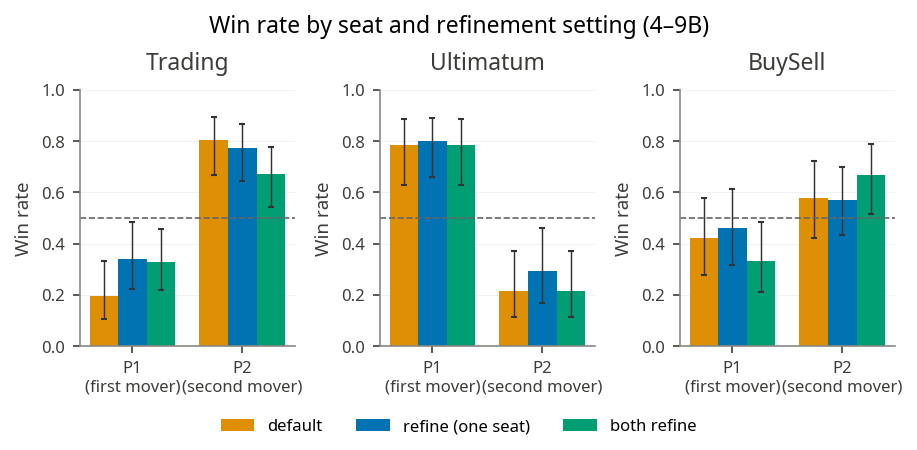

PLOT_DATA[winrate_refine_effect_by_seat_very_small]
[{"game":"BuySell","seat":1,"setting":"both","k":14,"n":42,"rate":0.333333,"lo":0.210125,"hi":0.484475},{"game":"BuySell","seat":1,"setting":"default","k":16,"n":38,"rate":0.421053,"lo":0.278525,"hi":0.578077},{"game":"BuySell","seat":1,"setting":"refine","k":18,"n":39,"rate":0.461538,"lo":0.315669,"hi":0.614306},{"game":"BuySell","seat":2,"setting":"both","k":28,"n":42,"rate":0.666667,"lo":0.515525,"hi":0.789875},{"game":"BuySell","seat":2,"setting":"default","k":22,"n":38,"rate":0.578947,"lo":0.421923,"hi":0.721475},{"game":"BuySell","seat":2,"setting":"refine","k":28,"n":49,"rate":0.571429,"lo":0.432705,"hi":0.699767},{"game":"Trading","seat":1,"setting":"both","k":19,"n":58,"rate":0.327586,"lo":0.220833,"hi":0.455759},{"game":"Trading","seat":1,"setting":"default","k":9,"n":46,"rate":0.195652,"lo":0.106506,"hi":0.331713},{"game":"Trading","seat":1,"setting":"refine","k":16,"n":47,"rate":0.340426,"lo":0.221674,"hi":0.483291},{"game

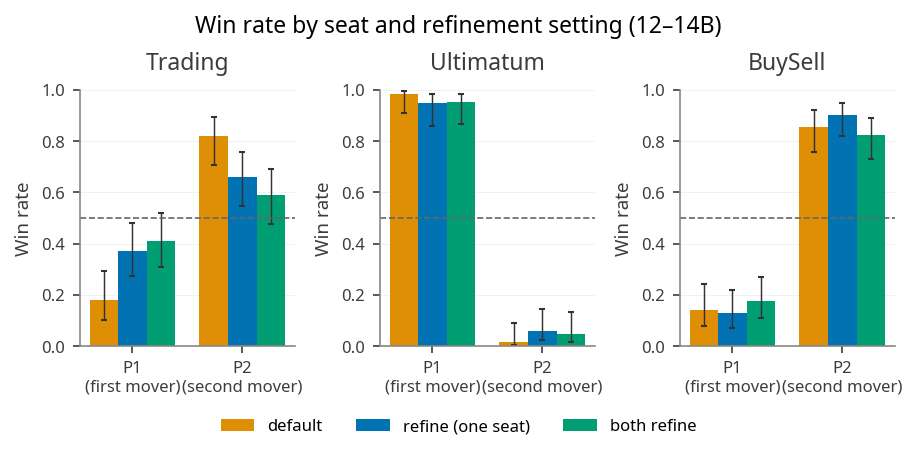

PLOT_DATA[winrate_refine_effect_by_seat_small]
[{"game":"BuySell","seat":1,"setting":"both","k":15,"n":85,"rate":0.176471,"lo":0.109964,"hi":0.270956},{"game":"BuySell","seat":1,"setting":"default","k":10,"n":70,"rate":0.142857,"lo":0.079489,"hi":0.243384},{"game":"BuySell","seat":1,"setting":"refine","k":10,"n":78,"rate":0.128205,"lo":0.071153,"hi":0.22016},{"game":"BuySell","seat":2,"setting":"both","k":70,"n":85,"rate":0.823529,"lo":0.729044,"hi":0.890036},{"game":"BuySell","seat":2,"setting":"default","k":60,"n":70,"rate":0.857143,"lo":0.756616,"hi":0.920511},{"game":"BuySell","seat":2,"setting":"refine","k":74,"n":82,"rate":0.902439,"lo":0.819128,"hi":0.949731},{"game":"Trading","seat":1,"setting":"both","k":32,"n":78,"rate":0.410256,"lo":0.307819,"hi":0.521119},{"game":"Trading","seat":1,"setting":"default","k":11,"n":61,"rate":0.180328,"lo":0.103791,"hi":0.294742},{"game":"Trading","seat":1,"setting":"refine","k":30,"n":81,"rate":0.37037,"lo":0.273317,"hi":0.479163},{"game":"Tra

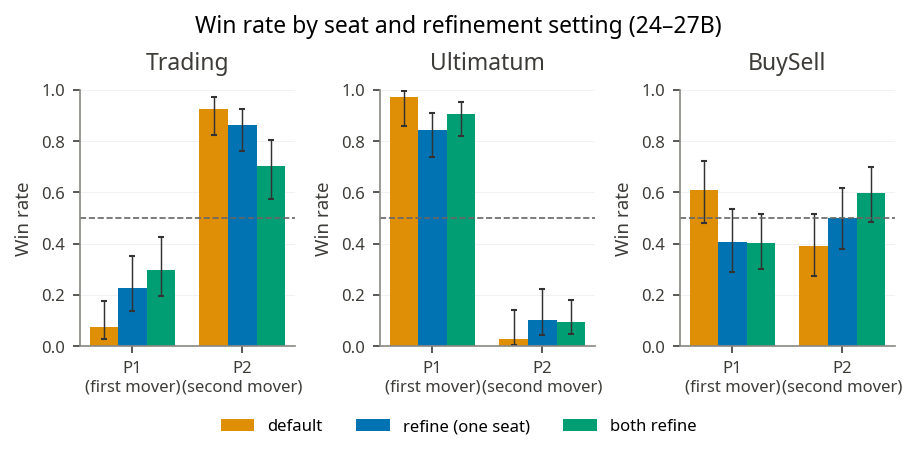

PLOT_DATA[winrate_refine_effect_by_seat_medium]
[{"game":"BuySell","seat":1,"setting":"both","k":31,"n":77,"rate":0.402597,"lo":0.30022,"hi":0.514231},{"game":"BuySell","seat":1,"setting":"default","k":36,"n":59,"rate":0.610169,"lo":0.482663,"hi":0.724206},{"game":"BuySell","seat":1,"setting":"refine","k":24,"n":59,"rate":0.40678,"lo":0.29089,"hi":0.534066},{"game":"BuySell","seat":2,"setting":"both","k":46,"n":77,"rate":0.597403,"lo":0.485769,"hi":0.69978},{"game":"BuySell","seat":2,"setting":"default","k":23,"n":59,"rate":0.389831,"lo":0.275794,"hi":0.517337},{"game":"BuySell","seat":2,"setting":"refine","k":32,"n":64,"rate":0.5,"lo":0.381021,"hi":0.618979},{"game":"Trading","seat":1,"setting":"both","k":17,"n":57,"rate":0.298246,"lo":0.195326,"hi":0.426643},{"game":"Trading","seat":1,"setting":"default","k":4,"n":54,"rate":0.074074,"lo":0.029182,"hi":0.175541},{"game":"Trading","seat":1,"setting":"refine","k":13,"n":57,"rate":0.22807,"lo":0.138419,"hi":0.35206},{"game":"Trading","se

In [7]:
# Per-tier facet: seat-resolved win rate (ties excluded) under default / refine
# this seat / both, one panel per game.
def plot_seat_winrate(sz):
    out = OUT[sz]
    games_present = [g for g in GAME_ORDER if len(out[g])]
    if not games_present:
        print(f"[skip] no win-rate data for {sz}")
        return None
    seat_wr = []
    fig, axes = plt.subplots(1, len(games_present), figsize=(FULL_WIDTH, 2.9),
                             squeeze=False)
    axes = axes[0]
    group_x = np.arange(2); width = 0.26
    for ax, g in zip(axes, games_present):
        df = out[g]
        for i, s in enumerate(SEAT_SETTING):
            rates, los, his = [], [], []
            for seat in (1, 2):
                rate, k, n = seat_winrate(df, seat, s)
                lo, hi = wilson_ci(k, n)
                rates.append(rate); los.append(lo); his.append(hi)
                seat_wr.append(dict(size=sz, game=g, seat=seat, setting=s,
                                    rate=rate, k=k, n=n, lo=lo, hi=hi))
            pos = group_x + (i - 1) * width
            ax.bar(pos, rates, width, label=SETTING_LABEL[s], color=SETTING_COLORS[s])
            ax.errorbar(pos, rates,
                        yerr=errbars_from_ci(np.array(rates, float), list(zip(los, his))),
                        fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
        ax.axhline(0.5, ls="--", lw=0.8, color="0.4")
        ax.set_xticks(group_x, ["P1\n(first mover)", "P2\n(second mover)"])
        ax.set_title(g); ax.set_ylabel("Win rate"); ax.set_ylim(0, 1.0)
    fig.suptitle(f"Win rate by seat and refinement setting ({SIZE_LABEL[sz]})")
    fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
               ncols=3, frameon=False)
    save_plot(fig, f"winrate_refine_effect_by_seat_{sz}"); plt.show()
    print_plot_frame(
        f"winrate_refine_effect_by_seat_{sz}", pd.DataFrame(seat_wr),
        columns=["game", "seat", "setting", "k", "n", "rate", "lo", "hi"],
        sort_by=["game", "seat", "setting"],
        round_cols={"rate": 6, "lo": 6, "hi": 6})
    return pd.DataFrame(seat_wr)


for sz in SIZES:
    plot_seat_winrate(sz)

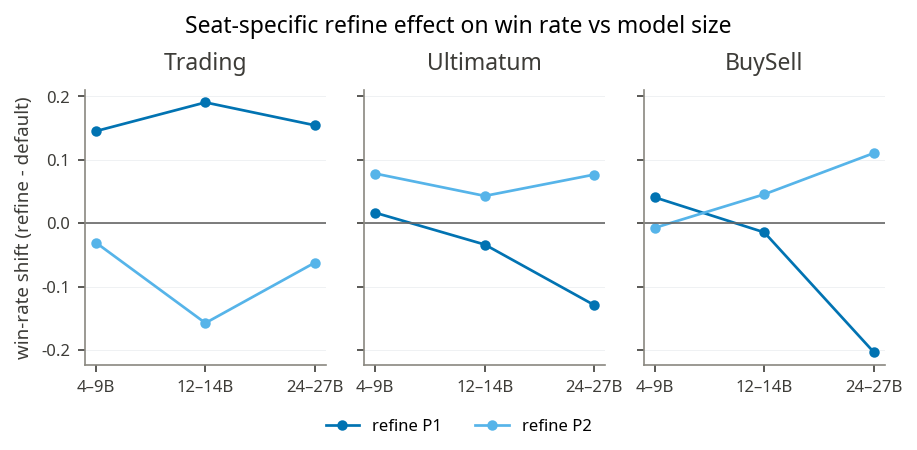

PLOT_DATA[refine_winrate_effect_by_tier]
[{"game":"BuySell","seat":"P1","size":"medium","default_wr":0.610169,"refine_wr":0.40678,"delta":-0.20339},{"game":"BuySell","seat":"P1","size":"small","default_wr":0.142857,"refine_wr":0.128205,"delta":-0.014652},{"game":"BuySell","seat":"P1","size":"very_small","default_wr":0.421053,"refine_wr":0.461538,"delta":0.040486},{"game":"BuySell","seat":"P2","size":"medium","default_wr":0.389831,"refine_wr":0.5,"delta":0.110169},{"game":"BuySell","seat":"P2","size":"small","default_wr":0.857143,"refine_wr":0.902439,"delta":0.045296},{"game":"BuySell","seat":"P2","size":"very_small","default_wr":0.578947,"refine_wr":0.571429,"delta":-0.007519},{"game":"Trading","seat":"P1","size":"medium","default_wr":0.074074,"refine_wr":0.22807,"delta":0.153996},{"game":"Trading","seat":"P1","size":"small","default_wr":0.180328,"refine_wr":0.37037,"delta":0.190043},{"game":"Trading","seat":"P1","size":"very_small","default_wr":0.195652,"refine_wr":0.340426,"delta":0.

In [8]:
# Tier trend: win-rate shift from refining a seat (refine-this-seat win rate
# minus the seat-matched DD win rate) vs model size, one panel per game, one
# line per seat.
wr_rows = []
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.9), sharey=True)
xs = np.arange(len(SIZES))
for ax, g in zip(axes, GAME_ORDER):
    for seat in (1, 2):
        ys = []
        for sz in SIZES:
            df = OUT[sz][g]
            base, _, bn = seat_winrate(df, seat, "default")
            ref, _, rn = seat_winrate(df, seat, "refine")
            d = (ref - base) if (bn and rn) else np.nan
            ys.append(d)
            wr_rows.append(dict(game=g, seat=f"P{seat}", size=sz,
                                default_wr=base, refine_wr=ref, delta=d))
        ax.plot(xs, np.array(ys, float), marker="o", ms=4, lw=1.3,
                color=SEAT_EFFECT_COLORS[seat], label=f"refine P{seat}")
    ax.axhline(0, lw=0.8, color="0.4")
    ax.set_xticks(xs, [SIZE_LABEL[s] for s in SIZES])
    ax.set_title(g)
axes[0].set_ylabel("win-rate shift (refine - default)")
fig.suptitle("Seat-specific refine effect on win rate vs model size")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
           ncols=2, frameon=False)
save_plot(fig, "refine_winrate_effect_by_tier"); plt.show()

print_plot_frame(
    "refine_winrate_effect_by_tier", pd.DataFrame(wr_rows),
    columns=["game", "seat", "size", "default_wr", "refine_wr", "delta"],
    sort_by=["game", "seat", "size"],
    round_cols={"default_wr": 6, "refine_wr": 6, "delta": 6})

**Reading section 2b (win rate).** The win-rate trend sharpens the redistribution
story. **Trading P1 is the one seat lifted at every tier** (`+0.15 / +0.19 /
+0.15`), while the already-winning Trading P2 is flat-to-negative
(`-0.03 / -0.16 / -0.06`) — the two seats move toward each other. The same
convergence appears in BuySell at `medium`, where the seller's win rate drops
`-0.20` as the buyer's rises `+0.11`, and in Ultimatum, where the proposer slips
(`-0.13` at medium) while the responder edges up (`+0.08`). Wherever a seat
starts away from the `0.5` parity line, refinement drags it back toward it.
Self-Refine is therefore better understood as a **variance-reducing, toward-
parity** operator than as a win-rate booster: it most helps the party that is
losing, and can cost the party that is winning.

### Matched default-vs-refine scatter

Hold `game x seat x family` fixed, put the seat's `DD` outcome on the x-axis and
the matched refined outcome on the y-axis. Points above the diagonal are gains
from refinement; points below are losses. One facet per tier. The payoff panel
uses each game's payoff span so the three games sit on the same 0-1 scale.

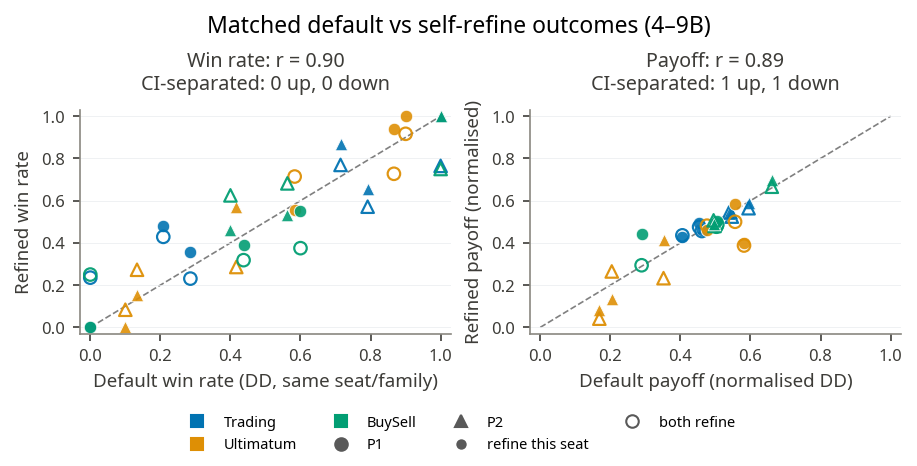

PLOT_DATA[default_vs_refine_scatter_very_small]
[{"game":"BuySell","family":"gemma","seat":1,"setting":"both","default_wr":0.0,"refined_wr":0.25,"wr_delta":0.25,"wr_rel":"overlap","default_pay":-11.083333,"refined_pay":-10.6,"pay_delta":0.483333,"pay_lo":-20.185,"pay_hi":21.033333,"pay_rel":"overlap","default_pay_norm":0.289167,"refined_pay_norm":0.294,"pay_norm_delta":0.004833},{"game":"BuySell","family":"gemma","seat":1,"setting":"refine","default_wr":0.0,"refined_wr":0.0,"wr_delta":0.0,"wr_rel":"overlap","default_pay":-11.083333,"refined_pay":4.0,"pay_delta":15.083333,"pay_lo":4.0,"pay_hi":27.0,"pay_rel":"refine>default","default_pay_norm":0.289167,"refined_pay_norm":0.44,"pay_norm_delta":0.150833},{"game":"BuySell","family":"ministral","seat":1,"setting":"both","default_wr":0.6,"refined_wr":0.375,"wr_delta":-0.225,"wr_rel":"overlap","default_pay":10.28,"refined_pay":7.652174,"pay_delta":-2.627826,"pay_lo":-7.365261,"pay_hi":2.299391,"pay_rel":"overlap","default_pay_norm":0.5028,"re

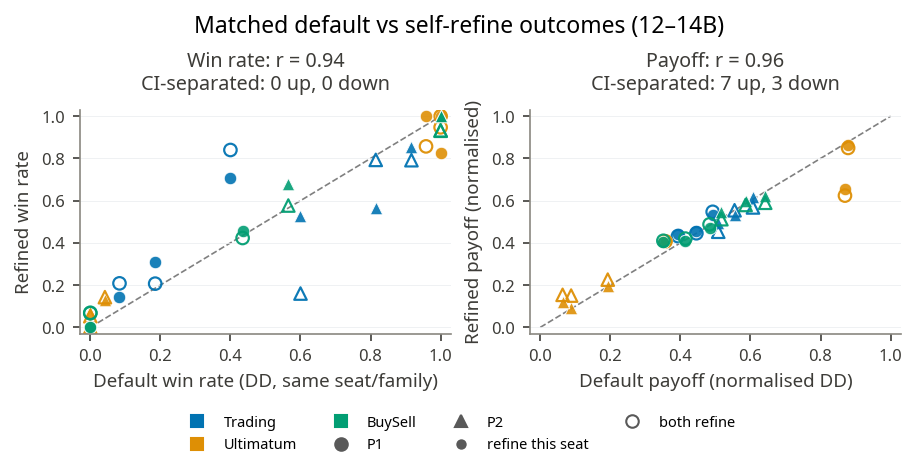

PLOT_DATA[default_vs_refine_scatter_small]
[{"game":"BuySell","family":"gemma","seat":1,"setting":"both","default_wr":0.0,"refined_wr":0.068966,"wr_delta":0.068966,"wr_rel":"overlap","default_pay":-4.866667,"refined_pay":1.0,"pay_delta":5.866667,"pay_lo":1.933333,"pay_hi":9.933333,"pay_rel":"refine>default","default_pay_norm":0.351333,"refined_pay_norm":0.41,"pay_norm_delta":0.058667},{"game":"BuySell","family":"gemma","seat":1,"setting":"refine","default_wr":0.0,"refined_wr":0.0,"wr_delta":0.0,"wr_rel":"overlap","default_pay":-4.866667,"refined_pay":0.206897,"pay_delta":5.073563,"pay_lo":1.407874,"pay_hi":9.037989,"pay_rel":"refine>default","default_pay_norm":0.351333,"refined_pay_norm":0.402069,"pay_norm_delta":0.050736},{"game":"BuySell","family":"ministral","seat":1,"setting":"both","default_wr":0.434783,"refined_wr":0.423077,"wr_delta":-0.011706,"wr_rel":"overlap","default_pay":8.310345,"refined_pay":8.777778,"pay_delta":0.467433,"pay_lo":-3.033365,"pay_hi":3.952842,"pay_rel":"ove

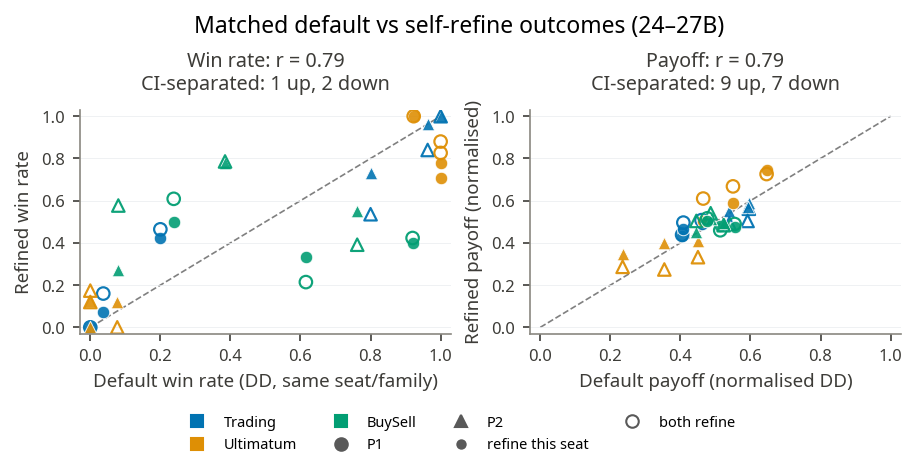

PLOT_DATA[default_vs_refine_scatter_medium]
[{"game":"BuySell","family":"gemma","seat":1,"setting":"both","default_wr":0.92,"refined_wr":0.423077,"wr_delta":-0.496923,"wr_rel":"refine<default","default_pay":15.466667,"refined_pay":8.933333,"pay_delta":-6.533333,"pay_lo":-9.533333,"pay_hi":-3.366667,"pay_rel":"refine<default","default_pay_norm":0.554667,"refined_pay_norm":0.489333,"pay_norm_delta":-0.065333},{"game":"BuySell","family":"gemma","seat":1,"setting":"refine","default_wr":0.92,"refined_wr":0.4,"wr_delta":-0.52,"wr_rel":"refine<default","default_pay":15.466667,"refined_pay":7.433333,"pay_delta":-8.033333,"pay_lo":-10.8,"pay_hi":-5.2325,"pay_rel":"refine<default","default_pay_norm":0.554667,"refined_pay_norm":0.474333,"pay_norm_delta":-0.080333},{"game":"BuySell","family":"ministral","seat":1,"setting":"both","default_wr":0.615385,"refined_wr":0.214286,"wr_delta":-0.401099,"wr_rel":"overlap","default_pay":11.368421,"refined_pay":5.966667,"pay_delta":-5.401754,"pay_lo":-9.072018

In [9]:
from matplotlib.lines import Line2D

PAYOFF_BOUNDS = {"Trading": (-30, 30), "Ultimatum": (0, 100), "BuySell": (-40, 60)}
GAME_COLORS = {"Trading": "#0173b2", "Ultimatum": "#de8f05", "BuySell": "#029e73"}
FAMILY_ORDER = ["gemma", "ministral", "qwen"]
FAMILY_LABEL = {"gemma": "Gemma", "ministral": "Ministral", "qwen": "Qwen"}
SEAT_MARKER = {1: "o", 2: "^"}
COMPARE_SETTINGS = ["refine", "both"]
COMPARE_LABEL = {"refine": "refine this seat", "both": "both refine"}


def norm_payoff(game, payoff):
    lo, hi = PAYOFF_BOUNDS[game]
    return (payoff - lo) / (hi - lo)


def _seat_fam_payoff_values(df, seat, setting, fam):
    col = "payoff_1" if seat == 1 else "payoff_2"
    sub = df[(df["cond"] == _SEAT_COND[(seat, setting)]) & (df["family"] == fam)]
    return sub[col].values.astype(float)


def _seat_fam_winrate(df, seat, setting, fam):
    sub = df[(df["cond"] == _SEAT_COND[(seat, setting)]) & (df["family"] == fam)]
    if seat == 1:
        w, l = int(sub["win_1"].sum()), int(sub["win_2"].sum())
    else:
        w, l = int(sub["win_2"].sum()), int(sub["win_1"].sum())
    rate, k, n = win_rate(w, l)
    lo, hi = wilson_ci(k, n)
    return rate, k, n, lo, hi


def _relation_from_ci(diff_lo, diff_hi, better="refine"):
    if diff_lo > 0:
        return f"{better}>default"
    if diff_hi < 0:
        return f"{better}<default"
    return "overlap"


def plot_matched_scatter(sz):
    out = OUT[sz]
    games_present = [g for g in GAME_ORDER if len(out[g])]
    if not games_present:
        print(f"[skip] no scatter data for {sz}")
        return None
    sr_rows = []
    for g in games_present:
        df = out[g]
        span = PAYOFF_BOUNDS[g][1] - PAYOFF_BOUNDS[g][0]
        for fam in FAMILY_ORDER:
            for seat in (1, 2):
                base_pay = _seat_fam_payoff_values(df, seat, "default", fam)
                base_wr, base_k, base_n, base_wr_lo, base_wr_hi = _seat_fam_winrate(df, seat, "default", fam)
                if len(base_pay) == 0:
                    continue
                base_pay_mean = float(np.mean(base_pay))
                for setting in COMPARE_SETTINGS:
                    ref_pay = _seat_fam_payoff_values(df, seat, setting, fam)
                    ref_wr, ref_k, ref_n, ref_wr_lo, ref_wr_hi = _seat_fam_winrate(df, seat, setting, fam)
                    if len(ref_pay) == 0:
                        continue
                    ref_pay_mean = float(np.mean(ref_pay))
                    pay_lo, pay_hi = _diff_ci(ref_pay, base_pay, seed=11 + seat + len(sr_rows))
                    wr_rel = "refine>default" if ref_wr_lo > base_wr_hi else (
                        "refine<default" if base_wr_lo > ref_wr_hi else "overlap")
                    sr_rows.append(dict(
                        size=sz, game=g, family=fam, seat=seat, setting=setting,
                        default_wr=base_wr, refined_wr=ref_wr, wr_delta=ref_wr - base_wr,
                        wr_rel=wr_rel, default_k=base_k, default_n=base_n,
                        refined_k=ref_k, refined_n=ref_n,
                        default_pay=base_pay_mean, refined_pay=ref_pay_mean,
                        pay_delta=ref_pay_mean - base_pay_mean,
                        pay_lo=pay_lo, pay_hi=pay_hi,
                        pay_rel=_relation_from_ci(pay_lo, pay_hi),
                        default_pay_norm=norm_payoff(g, base_pay_mean),
                        refined_pay_norm=norm_payoff(g, ref_pay_mean),
                        pay_norm_delta=(ref_pay_mean - base_pay_mean) / span))
    SR_CMP = pd.DataFrame(sr_rows)
    if SR_CMP.empty:
        print(f"[skip] no matched cells for {sz}")
        return None

    fig, (ax_wr, ax_pay) = plt.subplots(1, 2, figsize=(FULL_WIDTH, 3.0))
    for ax in (ax_wr, ax_pay):
        ax.plot([0, 1], [0, 1], ls="--", color="0.5", lw=0.8, zorder=0)
        ax.set_xlim(-0.03, 1.03); ax.set_ylim(-0.03, 1.03)
    for _, r in SR_CMP.iterrows():
        marker = SEAT_MARKER[int(r.seat)]; color = GAME_COLORS[r.game]
        if r.setting == "refine":
            face, edge, lw, alpha = color, "white", 0.45, 0.9
        else:
            face, edge, lw, alpha = "none", color, 1.05, 0.95
        ax_wr.scatter(r.default_wr, r.refined_wr, s=36, marker=marker,
                      facecolors=face, edgecolors=edge, linewidth=lw, alpha=alpha, zorder=2)
        ax_pay.scatter(r.default_pay_norm, r.refined_pay_norm, s=36, marker=marker,
                       facecolors=face, edgecolors=edge, linewidth=lw, alpha=alpha, zorder=2)
    wr_r = SR_CMP[["default_wr", "refined_wr"]].corr().iloc[0, 1]
    pay_r = SR_CMP[["default_pay_norm", "refined_pay_norm"]].corr().iloc[0, 1]
    wr_up = int((SR_CMP.wr_rel == "refine>default").sum())
    wr_down = int((SR_CMP.wr_rel == "refine<default").sum())
    pay_up = int((SR_CMP.pay_rel == "refine>default").sum())
    pay_down = int((SR_CMP.pay_rel == "refine<default").sum())
    ax_wr.set_xlabel("Default win rate (DD, same seat/family)")
    ax_wr.set_ylabel("Refined win rate")
    ax_wr.set_title(f"Win rate: r = {wr_r:.2f}\nCI-separated: {wr_up} up, {wr_down} down", fontsize=9.5)
    ax_pay.set_xlabel("Default payoff (normalised DD)")
    ax_pay.set_ylabel("Refined payoff (normalised)")
    ax_pay.set_title(f"Payoff: r = {pay_r:.2f}\nCI-separated: {pay_up} up, {pay_down} down", fontsize=9.5)
    leg_game = [Line2D([], [], marker="s", ls="", color=GAME_COLORS[g], label=g) for g in games_present]
    leg_seat = [Line2D([], [], marker=SEAT_MARKER[s], ls="", color="0.35", label=f"P{s}") for s in (1, 2)]
    leg_setting = [
        Line2D([], [], marker="o", ls="", markerfacecolor="0.35", markeredgecolor="white",
               color="0.35", label="refine this seat"),
        Line2D([], [], marker="o", ls="", markerfacecolor="none", markeredgecolor="0.35",
               color="0.35", label="both refine")]
    fig.legend(handles=leg_game + leg_seat + leg_setting, loc="outside lower center",
               ncols=4, frameon=False, fontsize=7)
    fig.suptitle(f"Matched default vs self-refine outcomes ({SIZE_LABEL[sz]})")
    save_plot(fig, f"default_vs_refine_scatter_{sz}"); plt.show()
    print_plot_frame(
        f"default_vs_refine_scatter_{sz}", SR_CMP,
        columns=["game", "family", "seat", "setting", "default_wr", "refined_wr",
                 "wr_delta", "wr_rel", "default_pay", "refined_pay", "pay_delta",
                 "pay_lo", "pay_hi", "pay_rel", "default_pay_norm",
                 "refined_pay_norm", "pay_norm_delta"],
        sort_by=["game", "seat", "family", "setting"],
        round_cols={"default_wr": 6, "refined_wr": 6, "wr_delta": 6,
                    "default_pay": 6, "refined_pay": 6, "pay_delta": 6,
                    "pay_lo": 6, "pay_hi": 6, "default_pay_norm": 6,
                    "refined_pay_norm": 6, "pay_norm_delta": 6})
    return SR_CMP


for sz in SIZES:
    plot_matched_scatter(sz)

**Reading section 2c (matched scatter).** The diagonal view makes the "tracks the
baseline" claim concrete. Counting cells whose difference CI separates from the
diagonal: very_small `1 up / 1 down` (of 36 payoff cells), `small` `7 up /
3 down`, `medium` `9 up / 7 down`; win-rate cells almost never separate
(`0/0`, `0/0`, `1/2`). So even at `medium` roughly three-quarters of cells are
statistically indistinguishable from no-refine, and the detectable moves are
*balanced* between gains and losses — there is no uniform lift at any tier. The
clear payoff gains are concrete and interpretable, though: Trading-Qwen-P1 (all
tiers), BuySell-Gemma-P1 at very_small (`+15`, isolated and noisy), and a cluster
of Ultimatum wins at `medium` (Ministral P1 `+11.8`, Gemma P2 `+11.2`,
Qwen P1 `+9.7`). Gains exist; they are just local to specific game × seat ×
family cells, not a property of the method.

## 3. How does refinement change the move?

For each refined turn the offer is parsed from both the initial draft and the
committed move; `ambition_delta = final_offer - initial_offer` measures how the
loop moved it (positive = **more selfish**, negative = **more generous**;
`|ambition_delta| < 0.5` = **unchanged**; no offer at either end =
**no_proposal**). The refining seat is recoverable from turn parity (first mover
on even turns, second on odd). One facet per tier.

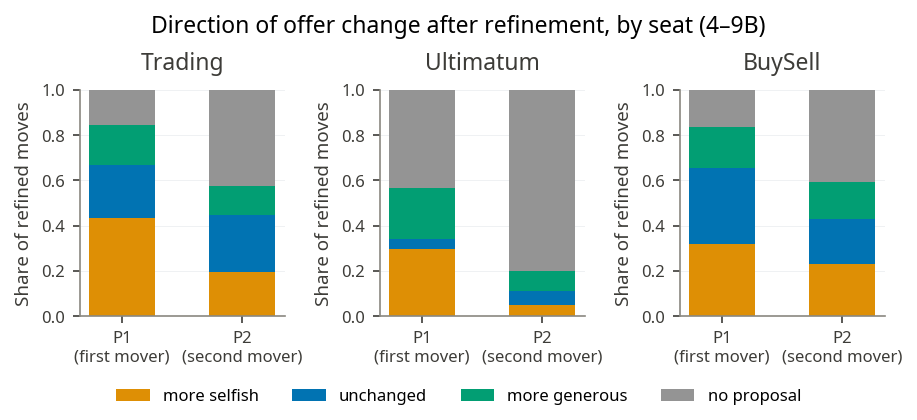

PLOT_DATA[refine_direction_by_seat_very_small]
[{"game":"buysell","seat":"P1","direction":"more_generous","n":38,"share":0.181818},{"game":"buysell","seat":"P1","direction":"more_selfish","n":67,"share":0.320574},{"game":"buysell","seat":"P1","direction":"no_proposal","n":34,"share":0.162679},{"game":"buysell","seat":"P1","direction":"unchanged","n":70,"share":0.334928},{"game":"buysell","seat":"P2","direction":"more_generous","n":28,"share":0.16092},{"game":"buysell","seat":"P2","direction":"more_selfish","n":40,"share":0.229885},{"game":"buysell","seat":"P2","direction":"no_proposal","n":71,"share":0.408046},{"game":"buysell","seat":"P2","direction":"unchanged","n":35,"share":0.201149},{"game":"trading","seat":"P1","direction":"more_generous","n":44,"share":0.175299},{"game":"trading","seat":"P1","direction":"more_selfish","n":109,"share":0.434263},{"game":"trading","seat":"P1","direction":"no_proposal","n":39,"share":0.155378},{"game":"trading","seat":"P1","direction":"unchanged","n

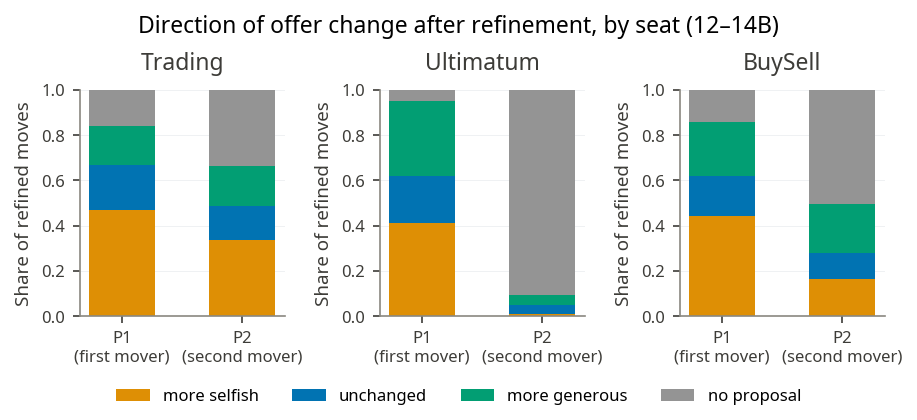

PLOT_DATA[refine_direction_by_seat_small]
[{"game":"buysell","seat":"P1","direction":"more_generous","n":62,"share":0.238462},{"game":"buysell","seat":"P1","direction":"more_selfish","n":115,"share":0.442308},{"game":"buysell","seat":"P1","direction":"no_proposal","n":37,"share":0.142308},{"game":"buysell","seat":"P1","direction":"unchanged","n":46,"share":0.176923},{"game":"buysell","seat":"P2","direction":"more_generous","n":45,"share":0.219512},{"game":"buysell","seat":"P2","direction":"more_selfish","n":34,"share":0.165854},{"game":"buysell","seat":"P2","direction":"no_proposal","n":103,"share":0.502439},{"game":"buysell","seat":"P2","direction":"unchanged","n":23,"share":0.112195},{"game":"trading","seat":"P1","direction":"more_generous","n":61,"share":0.171831},{"game":"trading","seat":"P1","direction":"more_selfish","n":166,"share":0.467606},{"game":"trading","seat":"P1","direction":"no_proposal","n":56,"share":0.157746},{"game":"trading","seat":"P1","direction":"unchanged","n":

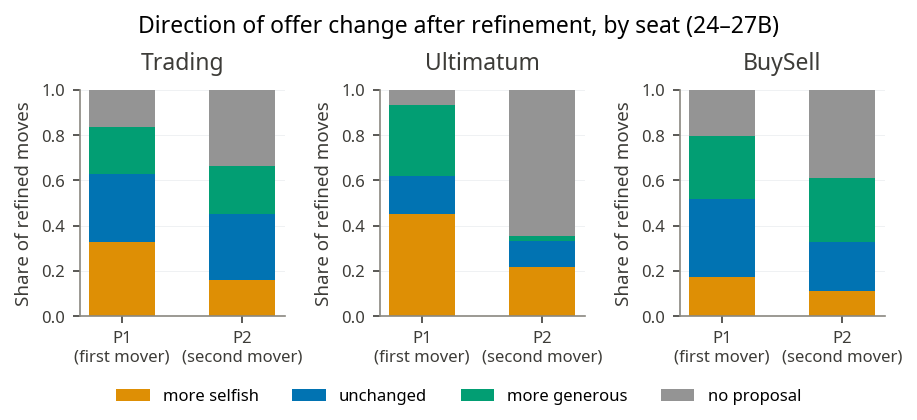

PLOT_DATA[refine_direction_by_seat_medium]
[{"game":"buysell","seat":"P1","direction":"more_generous","n":91,"share":0.279141},{"game":"buysell","seat":"P1","direction":"more_selfish","n":56,"share":0.171779},{"game":"buysell","seat":"P1","direction":"no_proposal","n":66,"share":0.202454},{"game":"buysell","seat":"P1","direction":"unchanged","n":113,"share":0.346626},{"game":"buysell","seat":"P2","direction":"more_generous","n":68,"share":0.283333},{"game":"buysell","seat":"P2","direction":"more_selfish","n":27,"share":0.1125},{"game":"buysell","seat":"P2","direction":"no_proposal","n":93,"share":0.3875},{"game":"buysell","seat":"P2","direction":"unchanged","n":52,"share":0.216667},{"game":"trading","seat":"P1","direction":"more_generous","n":72,"share":0.206897},{"game":"trading","seat":"P1","direction":"more_selfish","n":114,"share":0.327586},{"game":"trading","seat":"P1","direction":"no_proposal","n":57,"share":0.163793},{"game":"trading","seat":"P1","direction":"unchanged","n":105,

In [10]:
# Per-tier facet: direction of offer change after refinement, split by the seat
# that refined. TSUM is filtered to the tier in question.
def plot_direction(sz):
    tsum = TSUM_ALL[TSUM_ALL["size"] == sz].copy()
    if tsum.empty:
        print(f"[skip] no trace summary for {sz}")
        return None
    tsum["seat"] = np.where(tsum["turn_n"] % 2 == 0, "P1", "P2")
    dds = (tsum.groupby(["game", "seat", "direction"]).size()
           .rename("n").reset_index())
    tot = dds.groupby(["game", "seat"])["n"].transform("sum")
    dds["share"] = dds["n"] / tot
    games_present = [g for g in games_l if g in set(dds["game"])]
    seats = ["P1", "P2"]
    fig, axes = plt.subplots(1, len(games_present), figsize=(FULL_WIDTH, 2.7),
                             squeeze=False)
    axes = axes[0]
    xpos = np.arange(len(seats))
    for ax, g in zip(axes, games_present):
        bottom = np.zeros(len(seats))
        for d in DIRECTION_ORDER:
            vals = []
            for seat in seats:
                row = dds[(dds["game"] == g) & (dds["seat"] == seat)
                          & (dds["direction"] == d)]
                vals.append(float(row["share"].iloc[0]) if len(row) else 0.0)
            vals = np.array(vals)
            ax.bar(xpos, vals, 0.55, bottom=bottom, label=DIRECTION_LABEL[d],
                   color=DIRECTION_COLORS[d])
            bottom += vals
        ax.set_xticks(xpos, ["P1\n(first mover)", "P2\n(second mover)"])
        ax.set_ylim(0, 1.0); ax.set_title(game_disp[g])
        ax.set_ylabel("Share of refined moves")
    fig.suptitle(f"Direction of offer change after refinement, by seat ({SIZE_LABEL[sz]})")
    fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
               ncols=4, frameon=False)
    save_plot(fig, f"refine_direction_by_seat_{sz}"); plt.show()
    print_plot_frame(
        f"refine_direction_by_seat_{sz}", dds,
        columns=["game", "seat", "direction", "n", "share"],
        sort_by=["game", "seat", "direction"],
        round_cols={"share": 6})
    return dds


for sz in SIZES:
    plot_direction(sz)

**Reading section 3 (mechanism).** What is the loop actually doing to the move?
As size grows, the *no-proposal* share falls (`0.37 → 0.32 → 0.28`) and the
*unchanged* share rises (`0.20 → 0.16 → 0.25`): larger models fail-to-propose
less and make smaller, more deliberate edits instead of wholesale rewrites. The
self-interest tug — *more selfish* — peaks at the `small` tier (`0.33`) and
relaxes at `medium` (`0.24`), while *more generous* edits climb steadily with
size (`0.16 → 0.19 → 0.22`). This is the mechanism behind the section-2 payoff
swings: at `small` the loop most often pushes the offer in the proposer's own
favour (which is why refining the Ultimatum proposer there *over-corrects* into
generosity it cannot recover), whereas at `medium` the edit mix is balanced and
conservative. The per-seat split confirms the tug is not uniquely a first- or
second-mover phenomenon — both seats show the same broad mix at a given tier.

## 4. Seat × family

The pooled effect broken down by model family, kept seat-resolved. Bars give the
per-seat refine effect — refining that seat minus its own seat-matched `DD`
baseline — with bootstrap intervals on the difference, one model per family at
each tier. One facet per tier.

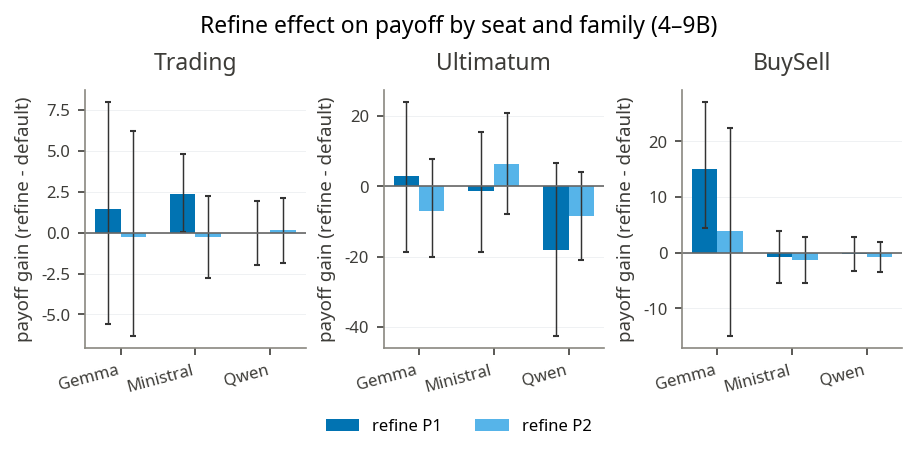

PLOT_DATA[refine_effect_by_family_seat_very_small]
[{"game":"BuySell","family":"gemma","seat":"P1","n":3,"delta":15.083333,"lo":4.416667,"hi":27.166667},{"game":"BuySell","family":"ministral","seat":"P1","n":23,"delta":-0.845217,"lo":-5.471435,"hi":3.890957},{"game":"BuySell","family":"qwen","seat":"P1","n":26,"delta":-0.266484,"lo":-3.313324,"hi":2.733585},{"game":"BuySell","family":"gemma","seat":"P2","n":9,"delta":3.916667,"lo":-14.975,"hi":22.388889},{"game":"BuySell","family":"ministral","seat":"P2","n":28,"delta":-1.291429,"lo":-5.413036,"hi":2.768607},{"game":"BuySell","family":"qwen","seat":"P2","n":30,"delta":-0.730952,"lo":-3.478631,"hi":1.843036},{"game":"Trading","family":"gemma","seat":"P1","n":15,"delta":1.466667,"lo":-5.601667,"hi":8.001667},{"game":"Trading","family":"ministral","seat":"P1","n":28,"delta":2.371429,"lo":0.04756,"hi":4.814524},{"game":"Trading","family":"qwen","seat":"P1","n":20,"delta":-0.016667,"lo":-1.950139,"hi":1.944861},{"game":"Trading","family":"g

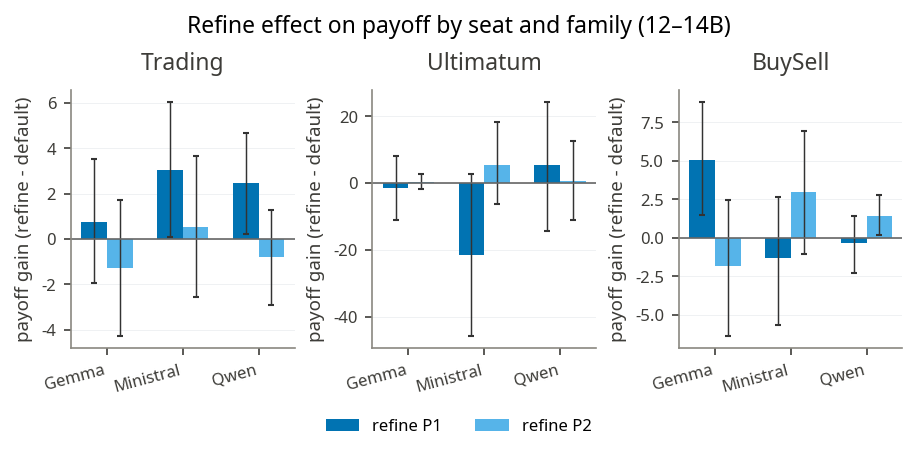

PLOT_DATA[refine_effect_by_family_seat_small]
[{"game":"BuySell","family":"gemma","seat":"P1","n":29,"delta":5.073563,"lo":1.47,"hi":8.845402},{"game":"BuySell","family":"ministral","seat":"P1","n":28,"delta":-1.310345,"lo":-5.658929,"hi":2.647876},{"game":"BuySell","family":"qwen","seat":"P1","n":30,"delta":-0.366667,"lo":-2.266667,"hi":1.400833},{"game":"BuySell","family":"gemma","seat":"P2","n":30,"delta":-1.833333,"lo":-6.366667,"hi":2.466667},{"game":"BuySell","family":"ministral","seat":"P2","n":28,"delta":2.953202,"lo":-1.061607,"hi":6.926847},{"game":"BuySell","family":"qwen","seat":"P2","n":30,"delta":1.4,"lo":0.2,"hi":2.8},{"game":"Trading","family":"gemma","seat":"P1","n":30,"delta":0.766667,"lo":-1.934167,"hi":3.533333},{"game":"Trading","family":"ministral","seat":"P1","n":30,"delta":3.05641,"lo":0.097244,"hi":6.046218},{"game":"Trading","family":"qwen","seat":"P1","n":29,"delta":2.441708,"lo":0.199959,"hi":4.666667},{"game":"Trading","family":"gemma","seat":"P2","n":30,"d

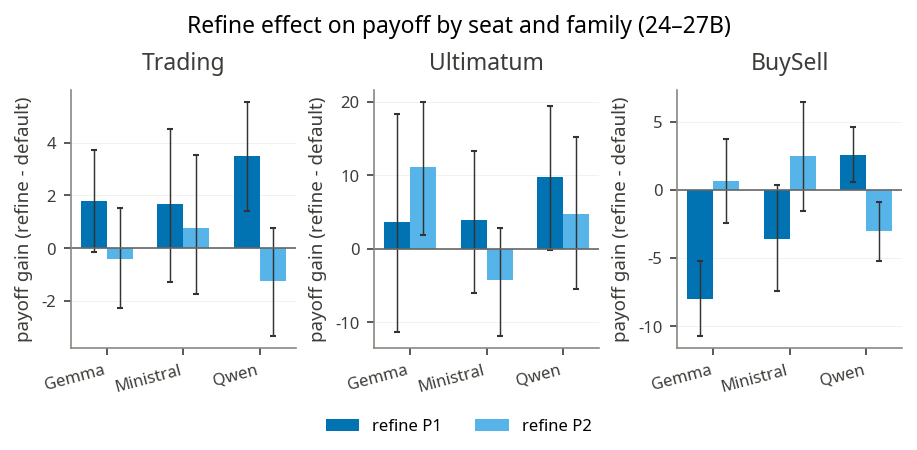

PLOT_DATA[refine_effect_by_family_seat_medium]
[{"game":"BuySell","family":"gemma","seat":"P1","n":30,"delta":-8.033333,"lo":-10.7,"hi":-5.233333},{"game":"BuySell","family":"ministral","seat":"P1","n":25,"delta":-3.568421,"lo":-7.383316,"hi":0.330737},{"game":"BuySell","family":"qwen","seat":"P1","n":29,"delta":2.551724,"lo":0.586207,"hi":4.62069},{"game":"BuySell","family":"gemma","seat":"P2","n":30,"delta":0.666667,"lo":-2.433333,"hi":3.734167},{"game":"BuySell","family":"ministral","seat":"P2","n":24,"delta":2.493421,"lo":-1.541721,"hi":6.465241},{"game":"BuySell","family":"qwen","seat":"P2","n":30,"delta":-3.011494,"lo":-5.193247,"hi":-0.888333},{"game":"Trading","family":"gemma","seat":"P1","n":29,"delta":1.783251,"lo":-0.146583,"hi":3.709452},{"game":"Trading","family":"ministral","seat":"P1","n":30,"delta":1.688889,"lo":-1.288889,"hi":4.511111},{"game":"Trading","family":"qwen","seat":"P1","n":5,"delta":3.5,"lo":1.416667,"hi":5.55},{"game":"Trading","family":"gemma","seat":"P2"

In [11]:
SEAT_EFFECT_FAM_COLORS = {"P1": "#0173b2", "P2": "#56b4e9"}


def _seat_fam_payoff(df, seat, setting, fam):
    cond = {(1, "default"): "DD", (1, "refine"): "RD",
            (2, "default"): "DD", (2, "refine"): "DR"}[(seat, setting)]
    col = "payoff_1" if seat == 1 else "payoff_2"
    sub = df[(df["cond"] == cond) & (df["family"] == fam)]
    return sub[col].values.astype(float)


def plot_seat_family(sz):
    out = OUT[sz]
    games_present = [g for g in GAME_ORDER if len(out[g])]
    if not games_present:
        print(f"[skip] no seat x family data for {sz}")
        return None
    sf_rows = []
    fig, axes = plt.subplots(1, len(games_present), figsize=(FULL_WIDTH, 2.9),
                             squeeze=False)
    axes = axes[0]
    x = np.arange(len(FAMILY_ORDER)); width = 0.34
    for ax, g in zip(axes, games_present):
        df = out[g]
        for i, (seat, tag) in enumerate([(1, "P1"), (2, "P2")]):
            deltas, los, his = [], [], []
            for fam in FAMILY_ORDER:
                base = _seat_fam_payoff(df, seat, "default", fam)
                ref = _seat_fam_payoff(df, seat, "refine", fam)
                if len(base) and len(ref):
                    d = ref.mean() - base.mean(); lo, hi = _diff_ci(ref, base)
                else:
                    d, lo, hi = np.nan, np.nan, np.nan
                deltas.append(d); los.append(lo); his.append(hi)
                sf_rows.append(dict(size=sz, game=g, family=fam, seat=tag,
                                    n=len(ref), delta=d, lo=lo, hi=hi))
            pos = x + (i - 0.5) * width
            ax.bar(pos, deltas, width, label=f"refine {tag}",
                   color=SEAT_EFFECT_FAM_COLORS[tag])
            ax.errorbar(pos, deltas,
                        yerr=errbars_from_ci(np.array(deltas, float), list(zip(los, his))),
                        fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
        ax.axhline(0, lw=0.8, color="0.4")
        ax.set_xticks(x, [FAMILY_LABEL[f] for f in FAMILY_ORDER], rotation=15, ha="right")
        ax.set_title(g); ax.set_ylabel("payoff gain (refine - default)")
    fig.suptitle(f"Refine effect on payoff by seat and family ({SIZE_LABEL[sz]})")
    fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
               ncols=2, frameon=False)
    save_plot(fig, f"refine_effect_by_family_seat_{sz}"); plt.show()
    print_plot_frame(
        f"refine_effect_by_family_seat_{sz}", pd.DataFrame(sf_rows),
        columns=["game", "family", "seat", "n", "delta", "lo", "hi"],
        sort_by=["game", "seat", "family"],
        round_cols={"delta": 6, "lo": 6, "hi": 6})
    return pd.DataFrame(sf_rows)


for sz in SIZES:
    plot_seat_family(sz)

**Reading section 4 (seat × family).** Disaggregating by family shows the pooled
Trading-P1 win is carried by specific models rather than shared across the board.
At `small` it is **Ministral** (`+3.06`, CI clears zero) and **Qwen** (`+2.44`,
CI clears zero); at `medium` it is **Qwen** (`+3.50`, CI clears zero), with Gemma
and Ministral positive but not separable. In Ultimatum the family bars are wide
and mostly overlap zero at every tier — the only family cells that clear zero are
at `medium` (Gemma P2 `+11.2`). The practical reading: when Self-Refine helps on
payoff, it is a **specific-model, specific-seat** effect, and the families that
benefit are not the same across tiers. There is no family for which refinement is
a dependable across-the-board improvement.

## Annex — impact heatmaps

For the appendix: a single scannable view of *where* refining one seat moves the
outcome. Rows are game x seat, columns are model tier. Each cell is the seat's
**refine-this-seat** value minus its **seat-matched default (DD)** baseline, so
positive (blue) = refinement helped that seat, negative (red) = it hurt.
**Bold** cells mark the seat that is *disadvantaged* on default at that tier
(win rate < 0.5); a trailing `*` marks a bootstrap 95% CI on the difference that
excludes zero. The win-rate panel is in probability units; the payoff panel is
annotated in native game units but colored on each game's payoff range so the
three games are visually comparable.

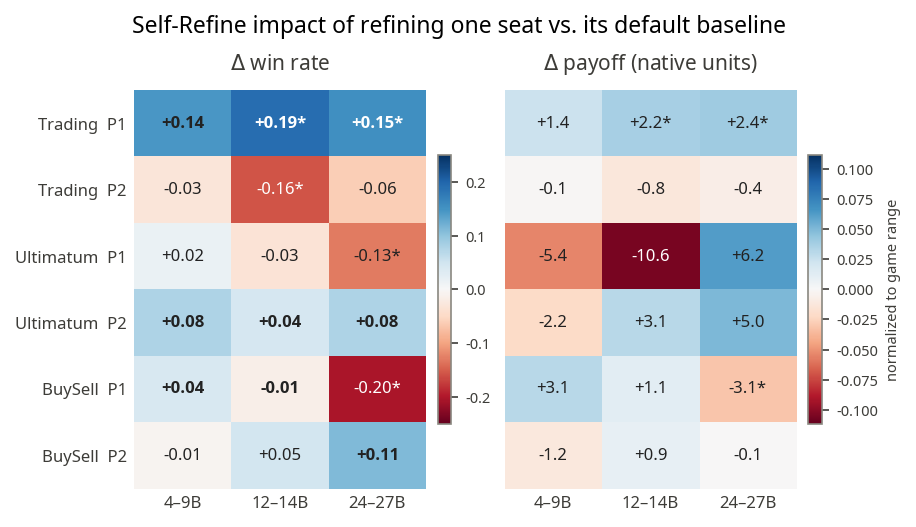

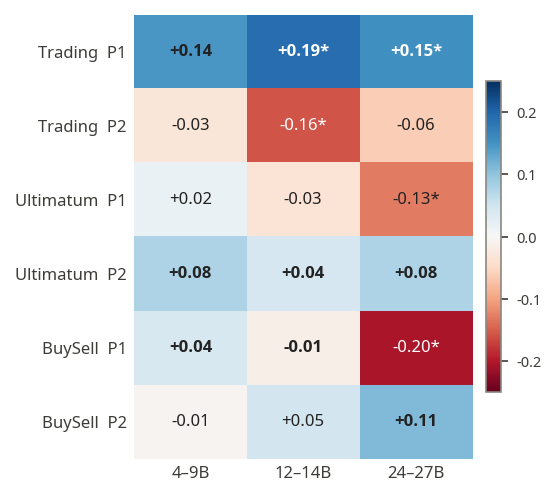

PLOT_DATA[refine_impact_heatmap]
[{"game":"Trading","seat":"P1","size":"very_small","wr_delta":0.1448,"wr_ci_excl0":false,"disadvantaged":true,"pay_delta":1.4127,"pay_ci_excl0":false},{"game":"Trading","seat":"P1","size":"small","wr_delta":0.19,"wr_ci_excl0":true,"disadvantaged":true,"pay_delta":2.2343,"pay_ci_excl0":true},{"game":"Trading","seat":"P1","size":"medium","wr_delta":0.154,"wr_ci_excl0":true,"disadvantaged":true,"pay_delta":2.3723,"pay_ci_excl0":true},{"game":"Trading","seat":"P2","size":"very_small","wr_delta":-0.0308,"wr_ci_excl0":false,"disadvantaged":false,"pay_delta":-0.0916,"pay_ci_excl0":false},{"game":"Trading","seat":"P2","size":"small","wr_delta":-0.1575,"wr_ci_excl0":true,"disadvantaged":false,"pay_delta":-0.7512,"pay_ci_excl0":false},{"game":"Trading","seat":"P2","size":"medium","wr_delta":-0.0623,"wr_ci_excl0":false,"disadvantaged":false,"pay_delta":-0.435,"pay_ci_excl0":false},{"game":"Ultimatum","seat":"P1","size":"very_small","wr_delta":0.0162,"wr_ci_excl0":

In [12]:
# Annex impact heatmaps: refine-one-seat minus seat-matched DD baseline.
# Win-rate delta (probability units) and payoff delta (native units, colored on
# each game's payoff range). Bold = disadvantaged seat (default WR < 0.5) at that
# tier; trailing * = bootstrap 95% CI on the difference excludes zero.
PAYOFF_BOUNDS = {"Trading": (-30, 30), "Ultimatum": (0, 100), "BuySell": (-40, 60)}

_rows = [(g, s) for g in GAME_ORDER for s in (1, 2)]
_row_labels = [f"{g}  P{s}" for (g, s) in _rows]
_col_labels = [SIZE_LABEL[s] for s in SIZES]


def _winprob_vec(df, seat, setting):
    """Ties-excluded 1/0 win vector for a seat under a setting (for the CI)."""
    sub = df[df["cond"] == _SEAT_COND[(seat, setting)]]
    decisive = sub[(sub["win_1"] == 1) | (sub["win_2"] == 1)]
    col = "win_1" if seat == 1 else "win_2"
    return decisive[col].values.astype(float)


wr_delta = np.full((len(_rows), len(SIZES)), np.nan)
wr_star = np.zeros_like(wr_delta, dtype=bool)
wr_disadv = np.zeros_like(wr_delta, dtype=bool)
pay_delta = np.full_like(wr_delta, np.nan)   # native units (annotation)
pay_norm = np.full_like(wr_delta, np.nan)    # normalized to game range (color)
pay_star = np.zeros_like(wr_delta, dtype=bool)
heat_rows = []

for i, (g, seat) in enumerate(_rows):
    lo_b, hi_b = PAYOFF_BOUNDS[g]
    for j, sz in enumerate(SIZES):
        df = OUT[sz][g]
        if df is None or not len(df):
            continue
        base_wr, _, base_n = seat_winrate(df, seat, "default")
        ref_wr, _, _ = seat_winrate(df, seat, "refine")
        if not np.isnan(base_wr) and not np.isnan(ref_wr):
            wr_delta[i, j] = ref_wr - base_wr
            wr_disadv[i, j] = base_wr < 0.5
            clo, chi = _diff_ci(_winprob_vec(df, seat, "refine"),
                                _winprob_vec(df, seat, "default"))
            wr_star[i, j] = (not np.isnan(clo)) and (clo > 0 or chi < 0)
        base_p, ref_p = seat_payoff(df, seat, "default"), seat_payoff(df, seat, "refine")
        if len(base_p) and len(ref_p):
            d = ref_p.mean() - base_p.mean()
            pay_delta[i, j] = d
            pay_norm[i, j] = d / (hi_b - lo_b)
            plo, phi = _diff_ci(ref_p, base_p)
            pay_star[i, j] = (not np.isnan(plo)) and (plo > 0 or phi < 0)
        heat_rows.append(dict(game=g, seat=f"P{seat}", size=sz,
                              wr_delta=wr_delta[i, j], wr_ci_excl0=bool(wr_star[i, j]),
                              disadvantaged=bool(wr_disadv[i, j]),
                              pay_delta=pay_delta[i, j], pay_ci_excl0=bool(pay_star[i, j])))


def _draw_heat(ax, annot, color, star, vmax, fmt, title, disadv=None):
    cm = plt.get_cmap("RdBu").copy(); cm.set_bad("#f0f0f0")
    im = ax.imshow(np.ma.masked_invalid(color), cmap=cm, vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(_col_labels)), _col_labels)
    ax.set_yticks(range(len(_row_labels)), _row_labels)
    ax.grid(False); ax.tick_params(length=0)
    for sp in ax.spines.values():
        sp.set_visible(False)
    for i in range(annot.shape[0]):
        for j in range(annot.shape[1]):
            if np.isnan(annot[i, j]):
                continue
            txt = fmt.format(annot[i, j]) + ("*" if star[i, j] else "")
            tc = "white" if abs(color[i, j]) > 0.6 * vmax else "#222222"
            fw = "bold" if (disadv is not None and disadv[i, j]) else "normal"
            ax.text(j, i, txt, ha="center", va="center", color=tc, fontsize=8, fontweight=fw)
    ax.set_title(title, fontsize=10)
    return im


fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 3.4))
im0 = _draw_heat(axes[0], wr_delta, wr_delta, wr_star, 0.25, "{:+.2f}",
                 r"$\Delta$ win rate", disadv=wr_disadv)
vmax_pay = float(np.nanmax(np.abs(pay_norm))) * 1.05
im1 = _draw_heat(axes[1], pay_delta, pay_norm, pay_star, vmax_pay, "{:+.1f}",
                 r"$\Delta$ payoff (native units)")
axes[1].set_yticklabels([])
cb0 = fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04); cb0.ax.tick_params(labelsize=7)
cb1 = fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
cb1.set_label("normalized to game range", fontsize=7); cb1.ax.tick_params(labelsize=7)
fig.suptitle("Self-Refine impact of refining one seat vs. its default baseline")
save_plot(fig, "refine_impact_heatmap"); plt.show()

# Standalone win-rate heatmap (unit-consistent; convenient as a single annex fig).
fig2, ax2 = plt.subplots(figsize=(HALF_WIDTH + 0.6, 3.2))
im = _draw_heat(ax2, wr_delta, wr_delta, wr_star, 0.25, "{:+.2f}", "", disadv=wr_disadv)
cb = fig2.colorbar(im, ax=ax2, fraction=0.046, pad=0.04); cb.ax.tick_params(labelsize=7)
save_plot(fig2, "refine_winrate_impact_heatmap"); plt.show()

print_plot_frame("refine_impact_heatmap", pd.DataFrame(heat_rows),
                 columns=["game", "seat", "size", "wr_delta", "wr_ci_excl0",
                          "disadvantaged", "pay_delta", "pay_ci_excl0"],
                 round_cols={"wr_delta": 4, "pay_delta": 4})


**Reading the annex heatmaps.** The win-rate panel localizes the headline
result: refining the **disadvantaged seat** helps only where the disadvantage is
positional and recoverable. The Trading first mover (P1) is the one row that is
positive *and* CI-robust at more than one tier (`+0.14 / +0.19* / +0.15*`), and
the Ultimatum proposer turns strongly positive once it is no longer dominant
(`medium`, `+0.08*` win rate alongside `+6.2` payoff). The clear red cell is the
**BuySell seller at `medium`** (`-0.20*` win rate, `-3.1*` payoff): refining a
contested seat there over-concedes. Disadvantaged seats with no slack (the
Ultimatum responder, P2) barely move. Net: a disadvantaged seat is helped by
Self-Refine only when its loss comes from *play*, not from *structure*.

## Verdict

**Overall, does Self-Refine help?** For these open-weight models, *no* — not as a
general improver of negotiation outcomes. The honest, evidence-weighted summary:

- **Format/completion: yes, and it scales with size.** This is the one benefit
  that is consistent across games and grows with capability (Trading completion
  lift `+0.05 → +0.18` across tiers). It is also the cheapest justification for
  the five-call cost — but it is *capability-gated*: on `very_small` the loop
  degrades completion, so it should not be enabled for the smallest models.
- **Payoff/win rate: mostly a wash, occasionally negative.** Pooled effects clear
  zero in only 2 of 18 payoff cells and essentially never in win rate. Refinement
  redistributes advantage **toward parity** — it lifts the seat that is behind and
  can hurt the seat that is ahead (BuySell seller at `medium`, Ultimatum proposer
  at `small`), rather than adding surplus.
- **Positive cases — yes, they exist and are specific:**
  1. **Trading first mover (P1)** — the only CI-robust, size-stable win, on both
     payoff and win rate, driven by Ministral and Qwen.
  2. **Completion in every game at `small` and `medium`.**
  3. **A cluster of Ultimatum cells at `medium`** (Ministral/Qwen proposer, Gemma
     responder) where payoff gains clear zero.

**Recommendation for the thesis.** Frame Self-Refine not as an outcome booster but
as a **format-repair-and-parity** mechanism: worth its cost where (a) the base
model is mid-tier or larger, and (b) the focal party is the structurally
disadvantaged seat (e.g. the Trading first mover). For a winning seat, or for the
smallest models, the extra calls are not justified by the outcomes observed here.